# Recursive Retrieval on a Lexical Graph

## Setup
- Create a venv if desired
  - `python3 -m venv venv`
  - `source venv/bin/activate`
- Install the packages:
  ```
  pip install networkx openai python-dotenv pymupdf pandas numpy pydantic \
      llama-index-core llama-index-llms-openai llama-index-embeddings-openai \
      llama-index-retrievers-bm25 PyStemmer langgraph langchain-core tiktoken
  ```
- Create a `.env` file containing only `OPENAI_API_KEY=...` (WhyHow keys are no longer needed).

## What changed from the WhyHow version
WhyHow is no longer available, so every WhyHow concept has been replaced by a local [NetworkX](https://networkx.org/) equivalent. Nothing is uploaded anywhere any more; the graphs live in memory and are cached to `./graph_data/`.

| WhyHow | NetworkX replacement |
|---|---|
| Workspace, schemas, uploaded CSV "documents" | Not needed |
| Chunk (CSV row, with embedding) | Node attributes: `text`, `properties`, `embedding` (embedded locally with OpenAI) |
| Node (`node_name` must be unique) | NetworkX node, keyed by the same `preview_hash` string |
| Triple (head, relation, tail) | Edge in a `MultiDiGraph`, with the relation name as the edge key |
| `query_structured(...)` | `graph.in_edges / out_edges` filtered by relation |
| `query_unstructured(...)` on the definitions graph | One GPT-4o call to pick relevant terms, then a graph lookup |

## Integration with Reducto

- As of the notebook's creation date, any developers interested in the Reducto API must reach out to founders to get a key for the demo.
- However, the [free demo on the website](https://app.reducto.ai/) allows up to 10 pages of text to be analyzed
- The API response JSONs can be copied and saved as `<pdf filename without extension>.json` under `docs_structure/reducto/`.



![Reducto Page](./img/reducto_page.png)
![Reducto Save JSON](./img/reducto_save_json.png)

- In our example, `bnm_compliance.pdf` in `/docs` was saved as `bnm_compliance.json` in `/docs_structure/reducto/`.
- This already has been done for you so you can run the notebook as-is – follow the steps above if you want to try with your own documents.

## Link Detection
<!-- <img src="./img/diagram.png" width="700px"> -->
![Diagram](./img/diagram.png)



- We use pymupdf to extract links from the documents.
- Pymupdf lets us access the locations of the links and the destination of the links (this applies to internal links that link to other parts of the document)
- We locate one Reducto element that is closest to the link's location, and another element closest to the link's destination, and establish a link between the two Reducto elements.
- This is what happens in the `extract_links_and_sections_to_elements` function.
- The output is a dataframe to visualize the links in the pdf


In [ ]:
# Colab: ~2 min. No runtime restart is required.
%pip install -q "pymupdf>=1.24" "llama-index-core>=0.12,<0.15" "llama-index-embeddings-openai>=0.3" "llama-index-llms-openai>=0.3" "llama-index-retrievers-bm25>=0.5" "PyStemmer>=2.2" "openai>=1.60" "langgraph>=0.2" "langchain-core>=0.3" "tiktoken>=0.7" "networkx>=3.0" "pandas" "numpy"

print("done — no runtime restart needed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.4/678.4 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.6/173.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 13.6 MB/s eta 0:00:00
done — no runtime restart needed


In [ ]:
import fitz
import pandas as pd
import numpy as np
import os
import math
import json
from collections import defaultdict
import hashlib
from typing import Dict, Any
FILENAME = "bnm_compliance"

# Unstructured didn't need this, but Reducto needed a vertical stretch to get accurate results
HEIGHT_ADJUSTMENT_FACTOR = 0.96


def calculate_distance(
    point1: tuple[float, float], point2: tuple[float, float]
) -> float:
    """Calculate the Euclidean distance between two points where a point is a two-item tuple for xy coords."""
    return math.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)


def point_to_segment_distance(
    px: float, py: float, ax: float, ay: float, bx: float, by: float
) -> float:
    """Calculate the minimum distance from point (px, py) to the segment (ax, ay) - (bx, by)."""
    dx, dy = bx - ax, by - ay
    if dx == dy == 0:  # the segment is a point
        return calculate_distance((px, py), (ax, ay))

    t = max(0, min(1, ((px - ax) * dx + (py - ay) * dy) / (dx * dx + dy * dy)))
    nearest = (ax + t * dx, ay + t * dy)
    return calculate_distance((px, py), nearest)


def min_distance_to_bbox(
    point: tuple[float, float], element_bbox_data: dict, pdf_path: str
) -> float:
    """Calculate the minimum distance from a point to a 4-point bounding box."""

    # Normalise pymupdf point to pymupdf's page resolution
    pymupdf_width, pymupdf_height = get_page_resolution_pymupdf(
        pdf_path, element_bbox_data["page"]
    )
    px, py = point
    px /= pymupdf_width
    py /= pymupdf_height

    # Normalise bbox points to Reducto's page resolution
    left, top, width, height = (
        element_bbox_data["left"],
        element_bbox_data["top"],
        element_bbox_data["width"],
        element_bbox_data["height"],
    )
    points = [
        (left, top),
        (left + width, top),
        (left + width, top + height),
        (left, top + height),
    ]
    bbox = [(x, y * HEIGHT_ADJUSTMENT_FACTOR) for x, y in points]

    distances = []

    # Calculate all combinations of point-to-segment distances
    for i in range(len(bbox)):
        ax, ay = bbox[i]
        bx, by = bbox[(i + 1) % len(bbox)]
        distances.append(point_to_segment_distance(px, py, ax, ay, bx, by))
    return min(distances)


def return_closest_elements(
    page_number: int,
    point: tuple[float, float],
    elements_by_pages: defaultdict,
    pdf_path: str,
) -> list:
    """
    Given pymupdf point coordinates and a page number, return a list of Reducto elements on the same
    page sorted by distance to the point. Used to find the corresponding Reducto element to a PDF link
    destination.
    """
    elements = elements_by_pages[page_number]
    sorted_elements = sorted(
        elements,
        key=lambda element: min_distance_to_bbox(point, element["bbox"], pdf_path),
    )
    return sorted_elements


def get_elements_sort_by_pages(file_name: str) -> defaultdict:
    """Retrieve and organise elements by pages from a Reducto output JSON file."""
    elements_file = f"{file_name}.json"

    with open(elements_file, "r") as f:
        data = json.load(f)

    elements_by_pages = defaultdict(list)

    for chunk in data["result"]["chunks"]:
        for element in chunk["blocks"]:
            elements_by_pages[element["bbox"]["page"]].append(element)

    return elements_by_pages


def get_elements(file_name: str) -> Dict[str, Any]:
    """Retrieve elements from a Reducto output JSON file."""
    elements_file = f"{file_name}.json"
    elements = {}

    with open(elements_file, "r") as f:
        data = json.load(f)

        for chunk in data["result"]["chunks"]:
            for element in chunk["blocks"]:
                page_number = int(element["bbox"]["page"])
                element_id = hash_element(element)
                elements[element_id] = element

    return elements


def get_page_resolution_pymupdf(pdf_path: str, page_number: int) -> tuple[float, float]:
    """Get the width and height of a specific page in a PDF document using pymupdf."""
    pdf_document = fitz.open(pdf_path)

    # Ensure the page number is valid
    if page_number < 1 or page_number > pdf_document.page_count:
        raise ValueError("Page number is out of range.")

    # Load the specified page (page_number is 1-based index)
    page = pdf_document.load_page(page_number - 1)

    # Get the page dimensions in points
    width = page.rect.width
    height = page.rect.height

    return width, height


def hash_element(element: dict) -> str:
    """Generate a hash for an element using its content and bounding box."""
    content = element["content"]
    bbox = str(element["bbox"]).encode("utf-8")
    return hashlib.md5(content.encode("utf-8") + bbox).hexdigest()

def unique_node_name(content, current_element_hash_id):
    """Generate a unique graph node ID from a content preview and the element hash."""
    clean_content = ' '.join(content.split())
    node_name_content_preview = clean_content[:50] + "..." if len(clean_content) > 50 else clean_content
    # node IDs have to be unique in the graph, so add the element hash to the end to make it unique
    node_name_content_preview += "_"
    node_name_content_preview += current_element_hash_id
    return node_name_content_preview

def extract_links_and_sections_to_elements(
    pdf_path: str, elements_by_pages: defaultdict
) -> tuple[pd.DataFrame, list[tuple]]:
    """
    Extract links from a PDF document and associate them with Reducto elements based on proximity.

    Returns a DataFrame containing the link information and a list of tuples representing links
    between elements.
    """
    document = fitz.open(pdf_path)
    links_data = []
    links_tuples = []

    for page_num in range(len(document)):
        page = document.load_page(page_num)
        links = page.get_links()

        for link in links:
            link_data = {}
            link_data["page_number"] = page_num + 1

            # Extract link text
            rect = fitz.Rect(link["from"])
            text = page.get_text("text", clip=rect)
            link_data["link_text"] = text.strip() if text else "No text"

            x, y, _, _ = link["from"]  # Get the coordinates of the link
            closest_elems = return_closest_elements(
                page_num + 1, (x, y), elements_by_pages, pdf_path
            )
            closest_elem = closest_elems[0] if closest_elems else None
            if closest_elem:
                link_data["guess_link_reducto_element"] = closest_elem["content"]
                link_element_id = hash_element(closest_elem)
            else:
                link_data["guess_link_reducto_element"] = "N/A"
                link_element_id = None

            # Determine link type and location
            if link["kind"] == fitz.LINK_GOTO:
                link_data["link_type"] = "internal"
                link_data["link_destination"] = "page " + str(
                    link["page"] + 1 if link["page"] >= 0 else "Unknown"
                )

                # Extract named destination if available
                dest = link.get("to", None)
                if dest:
                    link_data["named_destination"] = f"Coordinates: {dest}"
                    x, y = dest
                    target_page_num = link["page"] + 1
                    closest_elems = return_closest_elements(
                        target_page_num, (x, y), elements_by_pages, pdf_path
                    )
                    closest_elem = closest_elems[0] if closest_elems else None
                    if closest_elem:
                        link_data["guess_destination_reducto_element"] = closest_elem[
                            "content"
                        ]
                        link_destination_element_id = hash_element(closest_elem)
                    else:
                        link_data["guess_destination_reducto_element"] = "N/A"
                        link_destination_element_id = None
                else:
                    link_data["named_destination"] = "N/A"
                    link_data["guess_destination_reducto_element"] = "N/A"
                    link_destination_element_id = None

            elif link["kind"] == fitz.LINK_URI:
                link_data["link_type"] = "external"
                link_data["link_destination"] = link["uri"]
                link_data["named_destination"] = "N/A"
                link_data["guess_destination_reducto_element"] = "N/A"
                link_destination_element_id = link["uri"]
            else:
                link_data["link_type"] = "unknown"
                link_data["link_destination"] = "Unknown location"
                link_data["named_destination"] = "N/A"
                link_data["guess_destination_reducto_element"] = "N/A"
                link_destination_element_id = None

            # Keep track of tuples to create links later in Neo4j
            links_tuples.append((link_element_id, link_destination_element_id))
            links_data.append(link_data)

    df = pd.DataFrame(links_data)

    # Replace NaN and infinite values
    df.replace([np.inf, -np.inf, np.nan], "N/A", inplace=True)

    return df, links_tuples


def save_to_csv(df: pd.DataFrame, output_path: str) -> None:
    """Save a DataFrame to a CSV file at the specified path."""
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)


def analyse_links(
    filename: str, elements_by_pages: defaultdict
) -> tuple[pd.DataFrame, list[tuple]]:
    """
    Analyse links in a PDF document, matching them to Reducto elements, and saving the results to a CSV file.

    Returns a DataFrame with the link data and a list of tuples representing links between elements.
    """
    # Path to your PDF file
    pdf_path = f"{filename}.pdf"

    # Extract links to df
    links_df, links_tuples = extract_links_and_sections_to_elements(
        pdf_path, elements_by_pages
    )
    print("Links tuples: ", links_tuples)

    # Save DataFrame to CSV
    output_csv_path = f"docs_links/{filename}-with-reducto.csv"
    save_to_csv(links_df, output_csv_path)

    return links_df, links_tuples


# Example usage
links_df, links_tuples = analyse_links(
    FILENAME, get_elements_sort_by_pages(FILENAME)
)
links_df.head(200)

Links tuples:  [('f5f9f96d5d805f4e7d1ce832cc0e4937', '5feb986fe20fb5de66a9d110a602f280'), ('2cd1bcffc9bbdd0e7e590bfb22c52c1f', '1ce9f6267c7404bc6f29825b40c66c77'), ('c21822c0338a1563d5e8100467df1bc2', '1cc747588ddb4be5060534dd2d53eaba'), ('fabbe7be4a8a55626bc1d90782d54852', 'a878a69b7a0e10e0b5dd1f3c02c82049'), ('552896ac6f1046fe4f601afcdf5c6325', 'c097483e4d870f1651a3fbbf31e1f380'), ('42c2c25fccac1b063f84600d5807f3ff', 'da2a46ebf01d7a06d709c6c2fb8a0bda'), ('b432259b7584d0d856d4e444985de1c2', '499dcdb601259bb3cbce85ce364ed632'), ('2c517489527da348b5fc153b17b87057', '91f5ccdce7837fc5c8ab0b3ed7e14e54'), ('003d2a95aa3e44c56b28ca467f614446', '6cdf24899c11cedfa54a1f48658033a1'), ('39415dc21008fef7877cde99174cae62', '9898aabafc24b8c858516d18f8ca38fc'), ('baa81dc508fb8531ce35ede2c2246829', '0c30c80e8079513bcfb42217d016f720'), ('1cc747588ddb4be5060534dd2d53eaba', 'e4308cee3126ddd2a949650aeb69a368'), ('bbba75c05798bba059a8269b624befcb', '63f9a7375e9087b9974612325f288586'), ('bbba75c05798bba059a8

,page_number,link_text,guess_link_reducto_element,link_type,link_destination,named_destination,guess_destination_reducto_element
0,2,PART A OVERVIEW ............................,PART A OVERVIEW,internal,page 3,"Coordinates: Point(68.0, 83.91998)",PART A OVERVIEW
1,2,1 \nIntroduction ................................,1 Introduction,internal,page 3,"Coordinates: Point(68.0, 112.91998)",1 Introduction
2,2,2 \nApplicability ...............................,2 Applicability,internal,page 3,"Coordinates: Point(68.0, 671.92)",2.1 This policy document is applicable to all ...
3,2,3 \nLegal provisions ............................,3 Legal provisions,internal,page 4,"Coordinates: Point(68.0, 83.91998)",3 Legal provisions
4,2,4 \nEffective date ..............................,4 Effective date,internal,page 4,"Coordinates: Point(68.0, 229.91999)",4 Effective date
5,2,5 \nInterpretation ..............................,5 Interpretation,internal,page 4,"Coordinates: Point(68.0, 291.91999)",5 Interpretation
6,2,PART B POLICY REQUIREMENTS .................,PART B POLICY REQUIREMENTS,internal,page 6,"Coordinates: Point(68.0, 83.91998)",PART B POLICY REQUIREMENTS
7,2,6 \nResponsibilities of the board and senior m...,6 Responsibilities of the board and senior man...,internal,page 6,"Coordinates: Point(68.0, 112.91998)",6 Responsibilities of the board and senior man...
8,2,7 \nOrganisation of the compliance function .....,7 Organisation of the compliance function,internal,page 8,"Coordinates: Point(68.0, 345.91999)",\t- 7 Organisation of the compliance function
9,2,8 \nResponsibilities of the compliance functio...,8 Responsibilities of the compliance function,internal,page 10,"Coordinates: Point(68.0, 441.91999)",\t- 8 Responsibilities of the compliance function


# Building the Graphs with NetworkX

## Configuration and helpers
Loads the OpenAI client and defines small helpers: save/load a graph with `pickle`, and embed text in batches. WhyHow used to supply the node embeddings; now we compute them ourselves, so `EMBED_MODEL` must match the model used to embed queries in the LlamaIndex section below.

In [ ]:
import os
import csv
import json
import pickle
from collections import Counter, defaultdict
from enum import Enum
from typing import Any, Dict, List, Literal, Optional, Set, Tuple

import networkx as nx
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel

load_dotenv()

# Get OpenAI API key from environment variables
#openai_api_key = os.getenv("OPENAI_API_KEY")
openai_api_key="Paste you own OpenAI API Key here"
if openai_api_key is None:
    raise ValueError("OPENAI_API_KEY not found in environment variables.")

openai_client = OpenAI(api_key=openai_api_key)

# Node embeddings are computed with this model. It MUST be the same model that LlamaIndex uses to embed queries.
# (The original author found "AND" mode in the hybrid retriever works much better with 3072-dim embeddings:
#  to try that, set EMBED_MODEL = "text-embedding-3-large" and re-run from here.)
EMBED_MODEL = "text-embedding-3-small"
MAX_EMBED_CHARS = 20_000  # stay safely below the 8191-token input limit

GRAPH_DIR = "./graph_data"
os.makedirs(GRAPH_DIR, exist_ok=True)


def save_graph(graph: nx.Graph, path: str) -> None:
    """Persist a graph (including node embeddings) to disk."""
    with open(path, "wb") as f:
        pickle.dump(graph, f)
    print(f"Saved graph to {path}")


def load_graph(path: str) -> nx.Graph:
    with open(path, "rb") as f:
        return pickle.load(f)


def embed_texts(
    texts: List[str], model: str = EMBED_MODEL, batch_size: int = 100
) -> List[List[float]]:
    """Embed a list of texts with OpenAI, in batches. Empty strings are replaced so the API doesn't reject them."""
    embeddings: List[List[float]] = []
    for start in range(0, len(texts), batch_size):
        batch = [
            (t[:MAX_EMBED_CHARS] if t and t.strip() else "(empty content)")
            for t in texts[start : start + batch_size]
        ]
        response = openai_client.embeddings.create(model=model, input=batch)
        embeddings.extend(d.embedding for d in sorted(response.data, key=lambda d: d.index))
    return embeddings

## Building the definitions graph
GPT-4o extracts (term, definition) pairs from the definitions pages. They are cached to a CSV and loaded into a small graph: `Term --has_definition--> Definition`.

In [ ]:
class TermDefinition(BaseModel):
    """
    Pydantic schema used to describe the structured output of legal term-definition pairs for the GPT-4o model.
    """

    term: str
    definition: str


class TermDefinitionCSV(BaseModel):
    """
    Pydantic schema used to describe the structured output of legal term-definition pairs CSV for GPT-4o
    """

    content: List[TermDefinition]


class DefinitionGraphBuilder:
    """
    Given a range of pages, the builder extracts legal terms and their definitions from a PDF
    (found at `file_path`), saves them to a CSV, and loads them into a NetworkX graph:

        Term --has_definition--> Definition

    If extract_with_llm is False and the CSV already exists, no LLM calls are made:
    the existing CSV is simply loaded into a graph.
    """

    def __init__(
        self,
        definitions_page_ranges: List[Tuple[int, int]],  # page range starts count from 1
        file_path: str = f"{FILENAME}.pdf",
        definitions_csv_path: str = os.path.join(GRAPH_DIR, f"{FILENAME}_definitions.csv"),
        extract_with_llm: bool = True,
    ):
        self.definitions_page_ranges = definitions_page_ranges
        self.file_path = file_path
        self.definitions_csv_path = definitions_csv_path
        self.extract_with_llm = extract_with_llm
        self.graph: Optional[nx.DiGraph] = None

    def extract_and_save_to_csv(self) -> None:
        doc = fitz.open(self.file_path)

        all_terms_and_definitions = []

        # Flatten the list of ranges into individual pages
        page_numbers = []
        for start, end in self.definitions_page_ranges:
            page_numbers.extend(range(start, end + 1))

        for page_num in page_numbers:
            page = doc.load_page(page_num - 1)  # subtract 1 for 0-based index
            text = page.get_text("text")

            prompt = f"""
You will be shown a text from a page of a document containing legal terms and their definitions. Your task is to extract the legal terms and their corresponding definitions (verbatim) from the text and return them as the schema JSON.

Text:
{text}

Provide the extracted terms and definitions in the specified CSV format.
"""
            completion = openai_client.beta.chat.completions.parse(
                model="gpt-4o-2024-08-06",
                messages=[
                    {"role": "system", "content": "Extract the terms and definitions."},
                    {"role": "user", "content": prompt},
                ],
                response_format=TermDefinitionCSV,
            )

            terms_and_definitions = completion.choices[0].message.parsed.content
            print(f"page {page_num}: {terms_and_definitions}")

            for item in terms_and_definitions:
                all_terms_and_definitions.append((item.term, item.definition))

        os.makedirs(os.path.dirname(self.definitions_csv_path), exist_ok=True)
        with open(self.definitions_csv_path, "w", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(["Legal Term", "Definition"])
            for term, definition in all_terms_and_definitions:
                writer.writerow([term, definition])

        print(f"Created new CSV file, saved to {self.definitions_csv_path}")

    def load_pairs_from_csv(self) -> List[Tuple[str, str]]:
        with open(self.definitions_csv_path, "r", newline="") as csvfile:
            reader = csv.reader(csvfile)
            next(reader, None)  # skip header
            return [(row[0], row[1]) for row in reader if len(row) >= 2]

    def build_definitions_graph(self) -> nx.DiGraph:
        if self.extract_with_llm or not os.path.isfile(self.definitions_csv_path):
            self.extract_and_save_to_csv()

        graph = nx.DiGraph(name="Legal Definitions Graph")
        for term, definition in self.load_pairs_from_csv():
            definition_id = f"{term} (definition)"
            graph.add_node(term, label="Term", text=term)
            graph.add_node(definition_id, label="Definition", text=definition)
            graph.add_edge(term, definition_id, relation="has_definition")

        self.graph = graph
        print(f"Built definitions graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
        return graph


DEFINITIONS_GRAPH = DefinitionGraphBuilder(
    definitions_page_ranges=[(4, 5)],
    file_path=f"{FILENAME}.pdf",
    definitions_csv_path=os.path.join(GRAPH_DIR, f"{FILENAME}_definitions.csv"),
    extract_with_llm=True,  # set to False to reuse the CSV from a previous run
).build_definitions_graph()

page 4: [TermDefinition(term='Legal provisions', definition='This policy document is issued pursuant to–\n(a) section 47(1), section 115 and section 266 of the Financial Services Act 2013 (FSA);\n(b) section 57(1), section 127 and section 277 of the Islamic Financial Services Act 2013 (IFSA); and\n(c) section 41 and section 126 of the Development Financial Institutions Act 2002 (DFIA).'), TermDefinition(term='Effective date', definition='This policy document comes into effect on 1 January 2017.'), TermDefinition(term='Interpretation', definition='The terms and expressions used in this policy document shall have the same meanings assigned to them in the FSA, IFSA or DFIA, as the case may be, unless otherwise defined in this policy document.'), TermDefinition(term='S', definition='Denotes a standard, an obligation, a requirement, specification, direction, condition and any interpretative, supplemental and transitional provisions that must be complied with. Non-compliance may result in en

# Building the Lexical Graph with NetworkX

- Every Reducto element becomes a node in a `networkx.MultiDiGraph`.
- A node's ID is a preview (first 50 characters of the element's content) plus a hash of the Reducto element. This keeps IDs unique, readable in logs, and gives the LLM a little context whenever it sees an ID (see "Updating Node Context with Link Info").
- Edges carry the relation name as their key: `contains`, `is_parent`, `follows`, `links_to`.
- Node attributes: `label` (element type), `text`, `properties` (type, hash, page number, bbox, ...) and `embedding`.

In [ ]:
class ElementType(str, Enum):  # subclass of str so JSON serializable
    PAGE = "Page"
    TITLE = "Title"
    FIGURE = "Figure"
    FOOTER = "Footer"
    LIST_ITEM = "List Item"
    HEADER = "Header"
    DOCUMENT = "Document"
    SECTION_HEADER = "Section Header"
    TEXT = "Text"
    TABLE = "Table"


ELEMENTS = [ElementType.value for ElementType in ElementType]

# Relation names, used as edge keys in the graph
CONTAINS = "contains"  # an element containing another element (e.g. a list item and its indented sub-items)
IS_PARENT = "is_parent"  # a section being the parent of its elements
LINKS_TO = "links_to"  # a link in the pdf, from one element to another
FOLLOWS = "follows"  # keeps track of section header flow in the document


class NetworkXLexicalGraphBuilder:
    """
    Builds the lexical graph of a document as a networkx.MultiDiGraph from the Reducto JSON + PDF links.

    Node ID  : "<first 50 chars of content>..._<element hash>"  (Document node: the file name, cover page: "Cover Page")
    Node data: label (element type), text, properties (Type/Hash/Node Name/Content/Page Number/Location), embedding
    Edge key : the relation name (contains / is_parent / follows / links_to)
    """

    def __init__(self, file_name: str):
        self.file_name = file_name

        json_path = f"{file_name}.json"
        print("Loading JSON data...")
        if not os.path.isfile(json_path):
            raise FileNotFoundError(f"Reducto JSON file not found: {json_path}")
        with open(json_path, "r") as f:
            self.json_data = json.load(f)
        if not self.json_data:
            raise ValueError("No data found in JSON file.")
        print("JSON data loaded.")

        # (source element hash, destination element hash) pairs found by pymupdf + proximity matching
        elements_by_page_number = get_elements_sort_by_pages(file_name)
        self.links_tuples = analyse_links(file_name, elements_by_page_number)[1]

        self.graph = nx.MultiDiGraph(name=f"{file_name} Lexical Graph")
        # element hash -> node ID in the graph
        self.hash_to_node: Dict[str, str] = {}

    def _add_node(self, node_id: str, label: str, properties: Dict[str, Any], text: str) -> None:
        self.graph.add_node(node_id, label=label, properties=properties, text=text)

    def _link(self, head: Optional[str], tail: Optional[str], relation: str) -> bool:
        """Add head --relation--> tail. Silently ignores missing endpoints/self-loops. Re-adding the same relation is a no-op."""
        if head is None or tail is None or head == tail:
            return False
        if head not in self.graph or tail not in self.graph:
            return False
        self.graph.add_edge(head, tail, key=relation, relation=relation)
        return True

    def build_graph(self) -> nx.MultiDiGraph:
        doc_id = self.file_name
        cover_id = "Cover Page"

        self._add_node(doc_id, "Document", {"Type": "Document"}, text=doc_id)
        self._add_node(
            cover_id,
            "Page",
            {"Type": "Page", "Hash": "cover_page", "Node Name": cover_id, "Page Number": 1},
            text=cover_id,
        )
        self.hash_to_node["cover_page"] = cover_id
        self._link(doc_id, cover_id, CONTAINS)

        last_section_id: Optional[str] = None
        last_list_item_id: Optional[str] = None
        last_list_item_tabs = 0
        skipped = Counter()

        print("Creating nodes and structural edges...")
        for reducto_chunk in self.json_data["result"]["chunks"]:
            for element in reducto_chunk["blocks"]:
                element_type = element["type"]
                if element_type not in ELEMENTS or element_type in ("Page", "Document"):
                    skipped[element_type] += 1  # e.g. "Page Number" blocks
                    continue

                page_number = int(element["bbox"]["page"])
                raw_content = element["content"]
                content = raw_content if raw_content.strip() else "(empty content)"
                element_hash = hash_element(element)
                node_id = unique_node_name(content, element_hash)

                self._add_node(
                    node_id,
                    element_type,
                    {
                        "Type": element_type,
                        "Hash": element_hash,
                        "Node Name": node_id,
                        "Content": content,
                        "Page Number": page_number,
                        "Location": str(element["bbox"]),
                    },
                    text=content,
                )
                self.hash_to_node[element_hash] = node_id

                # Everything on page 1 hangs off the cover page
                if page_number == 1:
                    self._link(cover_id, node_id, CONTAINS)
                    continue

                # No section heading above yet: attach to the document
                if last_section_id is None:
                    self._link(doc_id, node_id, CONTAINS)

                if element_type == "Section Header":
                    self._link(last_section_id, node_id, FOLLOWS)
                    last_section_id = node_id
                    last_list_item_id = None  # reset: start of a new section
                    self._link(doc_id, node_id, CONTAINS)

                elif element_type == "List Item":
                    current_tabs = raw_content.count("\t")
                    if last_list_item_id is not None and current_tabs > last_list_item_tabs:
                        # an indented list item is contained by the last top-level list item
                        self._link(last_list_item_id, node_id, CONTAINS)
                    else:
                        # first list item in the section, or a new top-level list item
                        last_list_item_id = node_id
                        last_list_item_tabs = current_tabs
                        self._link(last_section_id, node_id, IS_PARENT)

                else:
                    self._link(last_section_id, node_id, IS_PARENT)

        # Link elements to each other, using the pairs of element hashes found in the PDF's hyperlinks.
        # External (URL) links have no destination node, and links whose two ends resolve to the same element are useless, so both are skipped.
        print("Adding links_to edges...")
        added_links = 0
        for source_hash, destination_hash in self.links_tuples:
            source = self.hash_to_node.get(source_hash)
            destination = self.hash_to_node.get(destination_hash)
            if self._link(source, destination, LINKS_TO):
                added_links += 1

        print(
            f"Done! {self.graph.number_of_nodes()} nodes, {self.graph.number_of_edges()} edges "
            f"({added_links} links_to). Skipped block types: {dict(skipped)}"
        )
        return self.graph


def add_embeddings(graph: nx.Graph, model: str = EMBED_MODEL) -> None:
    """Embed every node's text and store it as the node attribute 'embedding'."""
    node_ids = list(graph.nodes)
    texts = [graph.nodes[n]["text"] for n in node_ids]
    print(f"Embedding {len(texts)} nodes with {model}...")
    for node_id, embedding in zip(node_ids, embed_texts(texts, model)):
        graph.nodes[node_id]["embedding"] = embedding
    graph.graph["embed_model"] = model


LEXICAL_GRAPH_PATH = os.path.join(GRAPH_DIR, f"{FILENAME}_lexical_graph.pkl")
REBUILD_LEXICAL_GRAPH = True  # set to False to reuse the graph (and embeddings) saved by a previous run

if not REBUILD_LEXICAL_GRAPH and os.path.isfile(LEXICAL_GRAPH_PATH):
    LEXICAL_GRAPH = load_graph(LEXICAL_GRAPH_PATH)
    print(f"Loaded cached lexical graph from {LEXICAL_GRAPH_PATH}")
    if LEXICAL_GRAPH.graph.get("embed_model") != EMBED_MODEL:
        raise ValueError(
            f"Cached graph was embedded with {LEXICAL_GRAPH.graph.get('embed_model')}, "
            f"but EMBED_MODEL is {EMBED_MODEL}. Set REBUILD_LEXICAL_GRAPH = True."
        )
else:
    LEXICAL_GRAPH = NetworkXLexicalGraphBuilder(FILENAME).build_graph()
    add_embeddings(LEXICAL_GRAPH)
    save_graph(LEXICAL_GRAPH, LEXICAL_GRAPH_PATH)

Loading JSON data...
JSON data loaded.
Links tuples:  [('f5f9f96d5d805f4e7d1ce832cc0e4937', '5feb986fe20fb5de66a9d110a602f280'), ('2cd1bcffc9bbdd0e7e590bfb22c52c1f', '1ce9f6267c7404bc6f29825b40c66c77'), ('c21822c0338a1563d5e8100467df1bc2', '1cc747588ddb4be5060534dd2d53eaba'), ('fabbe7be4a8a55626bc1d90782d54852', 'a878a69b7a0e10e0b5dd1f3c02c82049'), ('552896ac6f1046fe4f601afcdf5c6325', 'c097483e4d870f1651a3fbbf31e1f380'), ('42c2c25fccac1b063f84600d5807f3ff', 'da2a46ebf01d7a06d709c6c2fb8a0bda'), ('b432259b7584d0d856d4e444985de1c2', '499dcdb601259bb3cbce85ce364ed632'), ('2c517489527da348b5fc153b17b87057', '91f5ccdce7837fc5c8ab0b3ed7e14e54'), ('003d2a95aa3e44c56b28ca467f614446', '6cdf24899c11cedfa54a1f48658033a1'), ('39415dc21008fef7877cde99174cae62', '9898aabafc24b8c858516d18f8ca38fc'), ('baa81dc508fb8531ce35ede2c2246829', '0c30c80e8079513bcfb42217d016f720'), ('1cc747588ddb4be5060534dd2d53eaba', 'e4308cee3126ddd2a949650aeb69a368'), ('bbba75c05798bba059a8269b624befcb', '63f9a7375e9087b9974

## Inspect the graph
Quick sanity check: node counts per element type, edge counts per relation, and a few sample edges.

In [ ]:
G = LEXICAL_GRAPH
print(G)
print("Nodes by type:    ", dict(Counter(d["label"] for _, d in G.nodes(data=True))))
print("Edges by relation:", dict(Counter(rel for _, _, rel in G.edges(keys=True))))

print("\nSample links_to edges:")
for head, tail, rel in [e for e in G.edges(keys=True) if e[2] == LINKS_TO][:5]:
    print(f"  {head}\n    --{rel}--> {tail}")

MultiDiGraph named 'bnm_compliance Lexical Graph' with 195 nodes and 232 edges
Nodes by type:     {'Document': 1, 'Page': 1, 'Figure': 1, 'Header': 12, 'Title': 1, 'Text': 22, 'List Item': 127, 'Footer': 18, 'Section Header': 12}
Edges by relation: {'contains': 95, 'is_parent': 99, 'follows': 11, 'links_to': 27}

Sample links_to edges:
  PART A OVERVIEW_f5f9f96d5d805f4e7d1ce832cc0e4937
    --links_to--> PART A OVERVIEW_5feb986fe20fb5de66a9d110a602f280
  1 Introduction_2cd1bcffc9bbdd0e7e590bfb22c52c1f
    --links_to--> 1 Introduction_1ce9f6267c7404bc6f29825b40c66c77
  2 Applicability_c21822c0338a1563d5e8100467df1bc2
    --links_to--> 2.1 This policy document is applicable to all fina..._1cc747588ddb4be5060534dd2d53eaba
  3 Legal provisions_fabbe7be4a8a55626bc1d90782d54852
    --links_to--> 3 Legal provisions_a878a69b7a0e10e0b5dd1f3c02c82049
  4 Effective date_552896ac6f1046fe4f601afcdf5c6325
    --links_to--> 4 Effective date_c097483e4d870f1651a3fbbf31e1f380


# Index with LlamaIndex
### Convert NetworkX nodes to local nodes, indexable with LlamaIndex

In [ ]:
from pydantic import BaseModel, ConfigDict
from typing import List, Dict, Any, Optional, Literal

from llama_index.core import SimpleDirectoryReader
from llama_index.core import StorageContext
from llama_index.core import Settings
from llama_index.core.schema import TextNode
from llama_index.llms.openai import OpenAI as LLamaOpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

from llama_index.core import VectorStoreIndex


Settings.llm = LLamaOpenAI(model="gpt-4o")
Settings.embed_model = OpenAIEmbedding(model_name=EMBED_MODEL)
storage_context = StorageContext.from_defaults()


class MultiAgentSearchLocalNode(TextNode):
    """
    An extended version of LlamaIndex's TextNode, with support for Element Types from Reducto
    Built from a node of the NetworkX lexical graph (its text, embedding and properties).
    Supports a tree-recursive print function for outputting structure as YAML for LLM calls
    """

    # A TextNode class was used because it supports indexing with LlamaIndex.
    class Config:
        arbitrary_types_allowed = True
        json_encoders = {
            ElementType: lambda v: str(
                v
            )  # Ensure ElementType is serialized as a string
        }

    type: ElementType
    embedding: Optional[List[float]] = None
    metadata: Optional[Dict[str, Any]] = None
    children: Dict[str, "MultiAgentSearchLocalNode"] = {}
    context: Optional[Dict[str, Any]] = {}

    def __init__(self, *, graph: nx.Graph, graph_node_id: str, **data: Any):
        super().__init__(**data)
        try:
            attributes = graph.nodes[graph_node_id]
        except KeyError:
            raise ValueError(f"Node {graph_node_id} not found in graph")

        self.id_ = graph_node_id
        self.embedding = attributes.get("embedding")
        self.metadata = attributes["properties"]
        self.text = attributes["text"]

    # Implement hash and eq for use in dictionaries and sets
    def __hash__(self) -> int:
        return hash(self.node_id)

    # Implement hash and eq for use in dictionaries and sets
    def __eq__(self, other: object) -> bool:
        if isinstance(other, MultiAgentSearchLocalNode):
            return self.node_id == other.node_id
        return False

    # print node for prompt. use yaml to save tokens + better performance than json
    # recursive tree printing function
    # GPT will return with JSON
    def print_node_prompt(self, indent_level: int = 0, show_type=False) -> str:
        cleaned_text = " ".join(self.text.split())
        indent_unit = "  "
        indent = indent_unit * indent_level

        prompt = f"""{indent}- node_id: `{self.node_id}`"""

        if show_type:
            prompt += f"{indent}{indent_unit*2}type: {self.type}\n"

        prompt += f"{indent}{indent_unit*2}content: {cleaned_text}"

        if self.context.items():
            context = ""
            for key, value in self.context.items():
                if value not in [None, "", " "]:
                    context += f"{indent}{indent_unit*3}- {key}: {value}\n"
            prompt += f"{indent}{indent_unit*2}context:\n"
            prompt += f"{context}\n"
        children = list(self.children.values())
        if len(children) > 0:
            prompt += f"{indent}{indent_unit*2}children: \n"
            for child in children:
                prompt += f"{child.print_node_prompt(indent_level = indent_level + 5)}"
        return prompt



def graph_node_to_local_node(
    graph_node_id: str, graph: Optional[nx.Graph] = None
) -> MultiAgentSearchLocalNode:
    """Build a local (LlamaIndex-compatible) node from a node ID in the lexical graph."""
    if graph is None:
        graph = LEXICAL_GRAPH
    return MultiAgentSearchLocalNode(
        graph=graph,
        graph_node_id=graph_node_id,
        type=ElementType(graph.nodes[graph_node_id]["label"]),
    )

/tmp/ipykernel_4437/1375289353.py:19: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  class MultiAgentSearchLocalNode(TextNode):


## Creating Nodes for multi-agent search

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
openai_api_key = os.environ["OPENAI_API_KEY"]

In [ ]:
local_nodes_map: Dict[str, MultiAgentSearchLocalNode] = {
    node_id: graph_node_to_local_node(node_id) for node_id in LEXICAL_GRAPH.nodes
}
print(f"Created {len(local_nodes_map)} local nodes")

Created 195 local nodes


#### Making sure all nodes have the same embedding

In [ ]:
node_embedding_lengths = [len(node.embedding) for node in local_nodes_map.values()]

print("Minimum embedding length for nodes:", min(node_embedding_lengths))
print("Maximum embedding length for nodes:", max(node_embedding_lengths))

Minimum embedding length for nodes: 1536
Maximum embedding length for nodes: 1536


## Hybrid Retriever (BM25 + Vector Search) with LlamaIndex
- A combination of BM25 and Vector Search

In [ ]:
from llama_index.core import QueryBundle

# import NodeWithScore
from llama_index.core.schema import NodeWithScore

from llama_index.core import SimpleKeywordTableIndex

# Retrievers
from llama_index.core.retrievers import (
    BaseRetriever,
    VectorIndexRetriever,
    KeywordTableSimpleRetriever,
)
from llama_index.retrievers.bm25 import BM25Retriever
from typing import List
import Stemmer

# Create a vector store using local nodes
vector_index = VectorStoreIndex(
    nodes=list(local_nodes_map.values()), storage_context=storage_context
)

keyword_index = SimpleKeywordTableIndex(
    nodes=list(local_nodes_map.values()), storage_context=storage_context
)


class BM25Keyword(BaseRetriever):
    """Custom retriever that performs both keyword search and BM25 search."""

    def __init__(
        self,
        mode: str = "OR",
        keyword_top_k=5,
        bm25_top_k=3,
    ) -> None:
        """Init params."""

        self._keyword_retriever = KeywordTableSimpleRetriever(
            index=keyword_index,
            max_keywords_per_query=keyword_top_k,
        )
        self._bm25_retriever = BM25Retriever.from_defaults(
            nodes=list(local_nodes_map.values()),
            similarity_top_k=bm25_top_k,
            # Optional: We can pass in the stemmer and set the language for stopwords
            # This is important for removing stopwords and stemming the query + text
            # The default is english for both
            stemmer=Stemmer.Stemmer("english"),
            language="english",
        )

        if mode not in ("AND", "OR"):
            raise ValueError("Invalid mode.")
        self._mode = mode
        super().__init__()

    def _retrieve(self, query_bundle: QueryBundle) -> List[MultiAgentSearchLocalNode]:
        """Retrieve nodes given query."""

        keyword_nodes = self._keyword_retriever.retrieve(query_bundle)
        bm25_nodes = self._bm25_retriever.retrieve(query_bundle)

        keyword_nodes_ids = {n.node.node_id for n in keyword_nodes}
        bm25_nodes_ids = {n.node.node_id for n in bm25_nodes}

        combined_dict = {n.node.node_id: n for n in keyword_nodes}
        combined_dict.update({n.node.node_id: n for n in bm25_nodes})

        if self._mode == "AND":
            retrieve_ids = keyword_nodes_ids.intersection(bm25_nodes_ids)
        else:
            retrieve_ids = keyword_nodes_ids.union(bm25_nodes_ids)

        retrieve_nodes = [combined_dict[rid] for rid in retrieve_ids]

        # print(f"Retrieved {len(retrieve_nodes)} nodes.")

        return retrieve_nodes


class VectorBM25(BaseRetriever):
    """Custom retriever that performs both semantic search and BM25 search."""

    def __init__(
        self,
        mode: str = "OR",
        vector_top_k=2,
        bm25_top_k=6,
    ) -> None:
        """Init params."""

        self._vector_retriever = VectorIndexRetriever(
            index=vector_index, similarity_top_k=vector_top_k, verbose=True
        )
        self._bm25_retriever = BM25Retriever.from_defaults(
            nodes=list(local_nodes_map.values()),
            similarity_top_k=bm25_top_k,
            # Optional: We can pass in the stemmer and set the language for stopwords
            # This is important for removing stopwords and stemming the query + text
            # The default is english for both
            stemmer=Stemmer.Stemmer("english"),
            language="english",
        )
        self._vector_top_k = vector_top_k
        self._bm25_top_k = bm25_top_k
        if mode not in ("AND", "OR"):
            raise ValueError("Invalid mode.")
        self._mode = mode
        super().__init__()

    def _retrieve(self, query_bundle: QueryBundle) -> List[MultiAgentSearchLocalNode]:
        """Retrieve nodes given query."""

        vector_nodes = self._vector_retriever.retrieve(query_bundle)
        bm25_nodes = self._bm25_retriever.retrieve(query_bundle)

        vector_ids = {n.node.node_id for n in vector_nodes}
        keyword_ids = {n.node.node_id for n in bm25_nodes}

        combined_dict = {n.node.node_id: n for n in vector_nodes}
        combined_dict.update({n.node.node_id: n for n in bm25_nodes})

        if self._mode == "AND":
            retrieve_ids = vector_ids.intersection(keyword_ids)
        else:
            retrieve_ids = vector_ids.union(keyword_ids)

        retrieve_nodes = [combined_dict[rid] for rid in retrieve_ids]

        # print(f"Retrieved {len(retrieve_nodes)} nodes.")

        return retrieve_nodes


from llama_index.core import get_response_synthesizer
from llama_index.core.query_engine import RetrieverQueryEngine

# Note: "AND" mode has qualitatively much better retriever performance,
# However, it only works best with embeddings of dim 3072. If you use "AND" mode on dim=1536, you retrieve zero nodes.
# To use dim=3072, set EMBED_MODEL = "text-embedding-3-large" in the configuration cell and re-run the notebook
# (the node embeddings are now computed in this notebook, so nothing else needs to change).

# define custom retriever
vector_bm25_retriever = VectorBM25(vector_top_k=2, bm25_top_k=6, mode="OR")
# bm25_retriever = BM25Keyword(keyword_top_k=5, bm25_top_k=3, mode="OR")
# keyword_retriever = BM25Keyword(keyword_top_k=5, bm25_top_k=3, mode="OR")

keyword_retriever = KeywordTableSimpleRetriever(
    index=keyword_index,
    max_keywords_per_query=6,
)
bm25_retriever = BM25Retriever.from_defaults(
    nodes=list(local_nodes_map.values()),
    similarity_top_k=6,
    # Optional: We can pass in the stemmer and set the language for stopwords
    # This is important for removing stopwords and stemming the query + text
    # The default is english for both
    stemmer=Stemmer.Stemmer("english"),
    language="english",
)

keywords_bm25_retriever = BM25Keyword(keyword_top_k=5, bm25_top_k=3, mode="OR")


response_synthesizer = get_response_synthesizer()


def retrieve_with_vector_bm25(query, verbose = False):
    retrieved_nodes: NodeWithScore = vector_bm25_retriever.retrieve(
        QueryBundle(query_str=query)
    )
    retrieved_nodes_local_form: MultiAgentSearchLocalNode = [
        local_nodes_map[node.node.node_id] for node in retrieved_nodes
    ]
    if verbose:
        for node in retrieved_nodes:
            print(node)
    return retrieved_nodes_local_form


def retrieve_with_bm25(query, verbose = False):
    retrieved_nodes: NodeWithScore = bm25_retriever.retrieve(
        QueryBundle(query_str=query)
    )
    retrieved_nodes_local_form: MultiAgentSearchLocalNode = [
        local_nodes_map[node.node.node_id] for node in retrieved_nodes
    ]
    if verbose:
        for node in retrieved_nodes:
            print(node)
    return retrieved_nodes_local_form


def retrieve_with_keywords(query, verbose = False):
    retrieved_nodes: NodeWithScore = keyword_retriever.retrieve(
        QueryBundle(query_str=query)
    )
    retrieved_nodes_local_form: MultiAgentSearchLocalNode = [
        local_nodes_map[node.node.node_id] for node in retrieved_nodes
    ]
    if verbose:
        for node in retrieved_nodes:
            print(node)
    return retrieved_nodes_local_form


def retrieve_with_keywords_bm25(query, verbose = False):
    retrieved_nodes: NodeWithScore = keywords_bm25_retriever.retrieve(
        QueryBundle(query_str=query)
    )
    retrieved_nodes_local_form: MultiAgentSearchLocalNode = [
        local_nodes_map[node.node.node_id] for node in retrieved_nodes
    ]
    if verbose:
        for node in retrieved_nodes:
            print(node)
    return retrieved_nodes_local_form


# Run this code to test the retrieval of documents
# vector_bm25_retriever("Return paragraph 7.3")
retrieve_with_keywords(
    "Return paragraph 7.3 and 7.4 to answer the query: How can the Board and the CCO manage control functions?", verbose=True
)

DEBUG:bm25s:Building index from IDs objects
DEBUG:bm25s:Building index from IDs objects
DEBUG:bm25s:Building index from IDs objects


Node ID: - S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3
Text: - S 7.4 In relation to paragraphs 7.2 and 7.3-
Score: None

Node ID: - S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05
Text: - S 7.6 Notwithstanding paragraph 7.3, the CCO of a large
financial institution is not allowed to assume the responsibilities of
other control functions.
Score: None

Node ID: - 1.4 This policy document sets out the following:_269ea6bee92395c2c67aabfba4d43863
Text: - 1.4 This policy document sets out the following:
Score: None

Node ID: - S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd
Text: - S 7.3 Where the CCO also assumes responsibilities for other
control functions, the CCO must ensure that his independence and
ability to provide sufficient time, focus and commitment to his
responsibilities in respect of the compliance function is not
impaired.
Score: None

Node ID: 1 Refer to the policy docu

[MultiAgentSearchLocalNode(id_='- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3', embedding=[-0.004268646240234375, 0.071044921875, 0.01446533203125, 0.023406982421875, 0.0020294189453125, 0.04962158203125, 0.0140380859375, -0.004276275634765625, -0.003997802734375, -0.040069580078125, 0.01158905029296875, 0.01727294921875, -0.0037403106689453125, 0.0034503936767578125, 0.0250396728515625, 0.0223541259765625, 0.030792236328125, 0.02532958984375, 0.030548095703125, 0.00518035888671875, 0.017425537109375, 0.0399169921875, 0.0244903564453125, 0.04595947265625, -0.0157012939453125, 0.0013227462768554688, -0.042724609375, 0.0131683349609375, 0.01525115966796875, -0.01496124267578125, 0.0352783203125, -0.037139892578125, 0.01629638671875, -0.01739501953125, 0.033294677734375, 0.01287841796875, 0.00440216064453125, 0.04608154296875, -0.038543701171875, 0.0281524658203125, 0.01425933837890625, 0.01458740234375, -0.00931549072265625, -0.0076141357421875, 0.016540

#### Hybrid Retriever (BM25 + Vector Search) test with LLM

In [ ]:
# Run this code to test the retriever + LLM answering
# print(response)
# retrieved_nodes = custom_retriever.retrieve(
#     QueryBundle(query_str="How can the Board and the CCO manage control functions?")
# )



# Recursive tree functions on subgraphs


In [ ]:
from typing import Dict
from typing import List, Any, Optional, Dict


def prune_node_from_nodes(
    nodes: List[MultiAgentSearchLocalNode],
    node_id: str,
) -> None:
    """Prune a node tree by node_id."""

    def prune(node: MultiAgentSearchLocalNode) -> bool:
        if node.node_id == node_id:
            return True
        to_delete = []
        for child_id, child_node in node.children.items():
            if prune(child_node):
                to_delete.append(child_id)
        for child_id in to_delete:
            del node.children[child_id]
        return False

    nodes[:] = [root_node for root_node in nodes if not prune(root_node)]


def recursive_update(
    nodes: List[MultiAgentSearchLocalNode],
    node_id: str,
    property: str,
    property_value: Any,
) -> None:
    """Recursively search a node tree by node_id and update the specified property with the given value."""

    def update_node(node: MultiAgentSearchLocalNode) -> bool:
        if node.node_id == node_id:
            setattr(node, property, property_value)
            return True
        for child in node.children.values():
            if update_node(child):
                return True
        return False

    for root_node in nodes:
        if update_node(root_node):
            break


def recursive_add_context(
    nodes: List[MultiAgentSearchLocalNode],
    node_id: str,
    context_key: str,
    context_value: str,
) -> None:
    """Recursively search a node tree by node_id and add a key-value pair to the context dictionary of the matching node."""

    def add_context_to_node(node: MultiAgentSearchLocalNode) -> bool:
        if node.node_id == node_id:
            node.context[context_key] = context_value
            return True
        for child in node.children.values():
            if add_context_to_node(child):
                return True
        return False

    for root_node in nodes:
        if add_context_to_node(root_node):
            break

    return nodes

def recursive_append_context_items(
    nodes: List[MultiAgentSearchLocalNode],
    node_id: str,
    context_key: str,
    new_items: List[str],
) -> None:
    """Recursively search a node tree by node_id and add a key-value pair to the context dictionary of the matching node."""

    def add_context_link_to_node(node: MultiAgentSearchLocalNode) -> bool:
        if node.node_id == node_id:
            node_links = node.context.get(context_key, [])
            node_links.append(new_items)
            node.context[context_key] = node_links

            return True
        for child in node.children.values():
            if add_context_link_to_node(child):
                return True
        return False

    for root_node in nodes:
        if add_context_link_to_node(root_node):
            break

    return nodes

def recursive_check_if_exists(
    nodes: List[MultiAgentSearchLocalNode],
    node_id: str,
) -> bool:
    """ Recursively search a node tree by node_id and check if the node exists."""

    def check_if_exists(node: MultiAgentSearchLocalNode) -> bool:
        if node.node_id == node_id:
            return True
        for child in node.children.values():
            if check_if_exists(child):
                return True
        return False

    for root_node in nodes:
        if check_if_exists(root_node):
            return True

    return False


# Tools for Agents

## Filtering out nodes that don't match a query

In [ ]:
from typing import Dict
from typing import List, Any, Optional, Dict

# Load environment variables
load_dotenv()

# Get OpenAI API key from environment variables
openai_api_key = os.getenv("OPENAI_API_KEY")
if openai_api_key is None:
    raise ValueError("OPENAI_API_KEY not found in environment variables.")

# Initialize OpenAI client
openai_client = OpenAI()
openai_client.api_key = openai_api_key


class PruneNodeIdResponse(BaseModel):
    """
    Pydantic schema used to describe a node via node_id being returned by the LLM.
    """

    node_id: str
    reason: str


class PruneNodeIdsResponse(BaseModel):
    """
    Pydantic schema used to describe nodes via node_ids being returned by the LLM.
    """

    content: List[PruneNodeIdResponse]


def prune_nodes(
    query: str, current_nodes: List[MultiAgentSearchLocalNode]
) -> List[MultiAgentSearchLocalNode]:
    """
    LLM call to remove any nodes that don't contain relevant information to the query.
    """

    starter_prompt = f"""
    You are an intelligent agent responsible for post-retrieval filtration of retrieved nodes from a document. The nodes are to answer the query:
    ```{query}```

    Below is a list of nodes that were automatically retrieved. Your task is to identify the nodes that do not contain relevant information to the query, and a short reason as to why they should be pruned.

    Be warned that deleting nodes will delete any sub-nodes listed within them.

    Nodes are identified by node_id. Return a list of (node_id, reason) where reason is a short explanation as to why the node should be pruned. node_ids must be quoted in backticks.

    """

    all_flattened_nodes : Dict[str, MultiAgentSearchLocalNode] = {}

    # node_id, (footer_text, further_explore_footer)

    def recurse_collect_nodes(current_nodes: List[MultiAgentSearchLocalNode]):
        """
        Recursively iterate via DFS on nodes, to index them by page number.
        """
        for node in current_nodes:
            all_flattened_nodes[node.id_] = node

            if len(node.children) > 0:
                recurse_collect_nodes(list(node.children.values()))

    recurse_collect_nodes(current_nodes)

    printout = ""
    for node in all_flattened_nodes.values():
        printout += node.print_node_prompt()

    completion = openai_client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": starter_prompt},
            {"role": "user", "content": printout},
        ],
        response_format=PruneNodeIdsResponse,
    )

    node_id_response = completion.choices[0].message.parsed.content

    prune_dictionary_results: Dict[str, str] = {}

    if isinstance(node_id_response, list):
        for item in node_id_response:
            if isinstance(item, PruneNodeIdResponse):
                if item.node_id[0] == "`":
                    node_id = item.node_id[1:-1]
                else:
                    node_id = item.node_id
                # print(f"Pruning node with node_id: {node_id} due to reason: {item.reason}")
                prune_dictionary_results[node_id] = item.reason
                prune_node_from_nodes(current_nodes, node_id)



    return current_nodes, prune_dictionary_results



local_nodes = list(local_nodes_map.values())
starting_nodes = local_nodes[100:110]


print("starting:")
for node in starting_nodes:
    print(node.print_node_prompt())

print("="*50)
print()

nodes_test1 , _= prune_nodes("How can CCO manage control functions?", starting_nodes)


for node in nodes_test1:
    print(node.print_node_prompt())

starting:
- node_id: `(b) ensure that the CCO has sufficient stature to ..._ade5bcb25050d514e6d10e163c1581ec`    content: (b) ensure that the CCO has sufficient stature to allow for effective engagement with the CEO and other members of senior management;
- node_id: `(c) engage with the CCO on a regular basis2 to pro..._75d9df850bf8422349822accdcb9338e`    content: (c) engage with the CCO on a regular basis2 to provide the opportunity for the CCO to discuss issues faced by the compliance function;
- node_id: `(d) provide the CCO with direct and unimpeded acce..._753739a7f2c2cf4c206b6e102cf20aca`    content: (d) provide the CCO with direct and unimpeded access to the board;
- node_id: `(e) ensure that the CCO is supported with sufficie..._b5cb66fa679baafeacc244e3dbe13938`    content: (e) ensure that the CCO is supported with sufficient resources, including competent officers, to perform his duties effectively; and
- node_id: `(f) where the CCO also carries out responsibilitie..._684a6af

## Collecting List Item Nodes for a clause

A clause be represented by a single List Item Node, or with a combination of List Item Nodes:

```
    CLAUSE 1                   CLAUSE 2                   
    +------------------------+   +--------------------+   
    | - Clause Title 1       |   | - Clause Title 2   |   
    |    - Subclause 1.1     |   +--------------------+   
    |    - Subclause 1.2     |                            
    +------------------------+                            
```

- There is a one to many relationship between Clause Title and Subclauses
  - Clause Title 1 -> Subclause 1.1
  - Clause Title 1 -> Subclause 2.1
- Vector/keyword search might only fetch a title or the subclause.
- We would have to traverse the nodes to fetch the whole clause.
  - Example (Assume there are only two levels: clause and subclause):
  ```
    # Example
    # Input:  [Section_Heading, Text, List_Item(Subclause 1.2), Image]

    # Output: [Section_Heading, Text, List_Item(Clause 1 Title), Image]
    #                                   └── [List_Item(Subclause 1.1), List_Item(Subclause 1.2)]
  ```

  Since we have a depth of 2 max, we will have to run the query twice to guarantee we will fetch the whole clause
    - Step 1: fetch any titles of subclauses. this step will have fetched us all clause titles
      - We will get Triples of X contains List Item Y
        - If a non List Item X contains List Item Y, by deduction, we can say that List Item Y is a clause title since there is nothing above it
        - If a List Item X contains List Item Y, by deduction, we can say that List Item Y is a subclause since there is a List Item above containing it. And by definition, List Item X is a clause title
    - Step 2: based on all clause titles fetched in Step 1, we can fetch all subclauses.
      - We look for Triples of List Item X contains List Item Y
      - List Item X is clause title from Step 1, and thus List Item Y is a subclause


In [ ]:
from collections import defaultdict
from typing import Set, Dict, List


def fetch_whole_clause_lists(
    current_nodes: List[MultiAgentSearchLocalNode], graph: Optional[nx.MultiDiGraph] = None
) -> List[MultiAgentSearchLocalNode]:
    """
    Given a list of nodes will retrieve and replace subclauses with full clauses.
    Assumes that we have a flat sequence of nodes, not a tree of nodes.
    """
    # (Assume there are only two levels: clause and subclause)
    # Example
    # Input:  [Section_Heading, Text, List_Item(Subclause 1.2), Image]

    # Output: [Section_Heading, Text, List_Item(Clause 1 Title), Image]
    #                                   └── [List_Item(Subclause 1.1), List_Item(Subclause 1.2)]
    if graph is None:
        graph = LEXICAL_GRAPH

    def is_list_item(node_id: str) -> bool:
        return graph.nodes[node_id]["label"] == ElementType.LIST_ITEM.value

    def structural_parents(node_id: str) -> List[str]:
        # whoever "contains" this node or is its "is_parent"
        return [
            head
            for head, _, rel in graph.in_edges(node_id, keys=True)
            if rel in (CONTAINS, IS_PARENT)
        ]

    def list_item_children(node_id: str) -> List[str]:
        # edges are stored in insertion order, which is document order
        return [
            tail
            for _, tail, rel in graph.out_edges(node_id, keys=True)
            if rel == CONTAINS and is_list_item(tail)
        ]

    # clause title id -> clause title node (with all of its subclauses attached as children)
    clause_titles: Dict[str, MultiAgentSearchLocalNode] = {}
    # subclause id -> id of the clause title it belongs to
    subclause_to_clause_map: Dict[str, str] = {}

    def register_clause(title_id: str) -> None:
        if title_id in clause_titles:
            return
        title_node = graph_node_to_local_node(title_id, graph)
        for subclause_id in list_item_children(title_id):
            title_node.children[subclause_id] = graph_node_to_local_node(subclause_id, graph)
            subclause_to_clause_map[subclause_id] = title_id
        clause_titles[title_id] = title_node

    # Step 1: find the clause title of every List Item we were given.
    # If a List Item has a List Item parent, the parent is the clause title (the node is a subclause).
    # Otherwise (its parent is a section/document), the node is itself a clause title.
    # Step 2 (inside register_clause): fetch all subclauses of each clause title.
    for node in current_nodes:
        if node.type != ElementType.LIST_ITEM:
            continue
        list_item_parents = [p for p in structural_parents(node.id_) if is_list_item(p)]
        register_clause(list_item_parents[0] if list_item_parents else node.id_)

    final_nodes = []
    seen_clauses: Set[str] = set()
    for current_node in current_nodes:
        # if not a list item, keep as is
        if current_node.type != ElementType.LIST_ITEM:
            final_nodes.append(current_node)
            continue

        # a clause title, or a subclause (look up its clause title)
        if current_node.id_ in clause_titles:
            clause_id = current_node.id_
        else:
            clause_id = subclause_to_clause_map.get(current_node.id_)

        # only add each full clause once: later subclauses of a clause we've already added are dropped
        if clause_id is not None and clause_id not in seen_clauses:
            seen_clauses.add(clause_id)
            final_nodes.append(clause_titles[clause_id])

    return final_nodes


local_nodes = list(local_nodes_map.values())
starting_nodes = local_nodes[139:141]

nodes_test = fetch_whole_clause_lists(starting_nodes)

print("PROMPT:")
for node in nodes_test:
    print(node.print_node_prompt())

PROMPT:
- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.
- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities

## Definition Agent Search

In [ ]:
class RelevantTerms(BaseModel):
    """
    Pydantic schema used to describe the defined terms the LLM picked out of a query.
    """

    terms: List[str]


def definitions_search(query: str, graph: Optional[nx.DiGraph] = None) -> Dict[str, str]:
    """
    Search for definitions of terms in a question prompt and return them as a dictionary.

    The LLM only chooses WHICH defined terms appear in the query; the definitions themselves
    are then read verbatim from the graph, so they can't be hallucinated.
    """
    if graph is None:
        graph = DEFINITIONS_GRAPH

    # all defined terms in the graph, matched case-insensitively
    term_lookup = {
        node.lower(): node for node, data in graph.nodes(data=True) if data["label"] == "Term"
    }

    prompt = f"""
You are given a list of legal terms that have definitions, and a user query.
Return only the terms from the list that are relevant to, or appear in, the query. Use the exact spelling from the list.

Defined terms:
{json.dumps(list(term_lookup.values()))}
"""
    completion = openai_client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": query},
        ],
        response_format=RelevantTerms,
    )

    definitions_dict: Dict[str, str] = {}
    for term in completion.choices[0].message.parsed.terms:
        graph_term = term_lookup.get(term.strip().lower())
        if graph_term is None:
            continue
        for definition_id in graph.successors(graph_term):
            if graph.nodes[definition_id]["label"] == "Definition":
                definitions_dict[graph_term] = graph.nodes[definition_id]["text"]
                break

    return definitions_dict


definitions_dict = definitions_search("How can the Board and the CCO manage control functions?")


def print_prompt_definitions_dict(definitions_dict):
    prompt = "Relevant Definitions:\n"
    for term, definition in definitions_dict.items():
        prompt += f"{term}: {definition}\n"
    return prompt

print(print_prompt_definitions_dict(definitions_dict))
print(definitions_dict)

Relevant Definitions:
board: Means the board of directors of a financial institution, including a committee of the board where the responsibilities of the board set out in this policy document have been delegated to such a committee;
chief compliance officer: Means the senior officer of a financial institution, however styled, who is the central point of authority for a financial institution’s compliance matters and is responsible for providing an institution-wide view on the management of compliance risk;
control function: refers to a function that has a responsibility independent from business lines to provide objective assessment, reporting or assurance. This includes the risk management function, the compliance function and the internal audit function;

{'board': 'Means the board of directors of a financial institution, including a committee of the board where the responsibilities of the board set out in this policy document have been delegated to such a committee;', 'chief complia

# Updating Node Context with Footer Info

In [ ]:
from typing import Dict
from typing import List, Any, Optional, Dict

# Load environment variables
load_dotenv()

# Get OpenAI API key from environment variables
openai_api_key = os.getenv("OPENAI_API_KEY")
if openai_api_key is None:
    raise ValueError("OPENAI_API_KEY not found in environment variables.")

# Initialize OpenAI client
openai_client = OpenAI()
openai_client.api_key = openai_api_key


footer_nodes_by_page_number: Dict[int, List[MultiAgentSearchLocalNode]] = defaultdict(
    list
)

# build a map of footer nodes by page number
for node_id, node in local_nodes_map.items():
    if node.type == ElementType.FOOTER:
        page_number = int(node.metadata["Page Number"])
        footer_nodes_by_page_number[page_number].append(node)


class NodeIdFooterResponse(BaseModel):
    """
    Pydantic schema used to describe the structured output of node-id to footer info pair
    """

    node_id: str
    footer_text: str
    further_explore_footer: bool


class NodeIdFooterResponses(BaseModel):
    """
    Pydantic schema used to describe the structured output of node-id to footer info pairs.
    """

    content: List[NodeIdFooterResponse]


def fill_nodes_with_footer_context(
    query: str, current_nodes: List[MultiAgentSearchLocalNode]
) -> Tuple[List[MultiAgentSearchLocalNode], int]:
    """
    Takes nodes and returns a list of footer contexts to fill them with.
    """

    starter_prompt = f"""
    You are an agent responsible for the structured extraction of a document page to answer the question:
    ```{query}```
    Below are two lists of OCR'd text, one for nodes and one for footers. All the text was taken from one page. Some of these nodes make references to the footers below, possibly through footnote numbers.

    Your task is, for each node_id, to identify if it contains (1) any footer information, and (2) if the footer requires further reading ON THE SAME DOCUMENT. Return only node_ids that contain footer info.

    For each node:
    1. deduce from the context and footnode numbering if any footer content might be relevant to the node given the query. If so, extract that footer content (it can be a partial or whole extract) and assign it to the node. If there is no footer info, SKIP the node. Only return nodes that have footer content.

    2. Some of the footer content may require the reader to consult other parts of the document (it must be an internal link pointing to other paragraphs/sections, not external reading). If so, set the further_explore_footer flag to true, else false.

    Then return a list of (node_id, relevant_footer_content, further_explore_footer). node_ids must be quoted in backticks.

    """

    nodes_by_page_number: Dict[int, List[MultiAgentSearchLocalNode]] = defaultdict(list)

    # collection of which nodes to mark with footer context
                            #node_id, (footer_text, further_explore_footer)
    node_id_footer_context: Dict[str, Tuple[str, bool]] = {}


    def recurse_index_nodes(current_nodes: List[MultiAgentSearchLocalNode]):
        """
        Recursively iterate via DFS on nodes, to index them by page number.
        """
        for node in current_nodes:
            page_number = int(node.metadata["Page Number"])
            nodes_by_page_number[page_number].append(node)

            if len(node.children) > 0:
                recurse_index_nodes(list(node.children.values()))

    recurse_index_nodes(current_nodes)

    for page_number, nodes in nodes_by_page_number.items():

        printout_of_curent_nodes = f"Nodes on page {page_number}"
        for node in nodes:
            printout_of_curent_nodes += node.print_node_prompt()

        printout_of_footers = f"Footers on page {page_number}:"
        for footer in footer_nodes_by_page_number[page_number]:
            printout_of_footers += footer.print_node_prompt()

        completion = openai_client.beta.chat.completions.parse(
            model="gpt-4o-2024-08-06",
            messages=[
                {"role": "system", "content": starter_prompt},
                {"role": "user", "content": printout_of_curent_nodes},
                {"role": "user", "content": printout_of_footers},
            ],
            response_format=NodeIdFooterResponses,
        )

        node_id_footer_response = completion.choices[0].message.parsed.content

        if isinstance(node_id_footer_response, list):
            for item in node_id_footer_response:
                if isinstance(item, NodeIdFooterResponse):
                    # sometimes GPT returns node ids with or without backticks
                    if item.node_id[0] == "`":
                        node_id = item.node_id[1:-1]
                    else:
                        node_id = item.node_id
                    node_id_footer_context[node_id] = (item.footer_text, item.further_explore_footer)

    change_count = 0
    # Based on the dict of node_id - footer context
    for node_id, (footer_text, further_explore_footer) in node_id_footer_context.items():
        # some LLM calls
        if footer_text not in ["", " ", None]:
            # print(f"node_id: {node_id}, footer_text: '{footer_text}', further_explore_footer: {further_explore_footer}")
            recursive_add_context(current_nodes, node_id, "footer info", footer_text)
            recursive_add_context(current_nodes, node_id, "further explore footer?", str(further_explore_footer))
            change_count += 1

    return current_nodes, change_count


local_nodes = list(local_nodes_map.values())
starting_nodes = local_nodes[100:110]

nodes_test1 = fetch_whole_clause_lists(starting_nodes)
nodes_test2, change_count = fill_nodes_with_footer_context("What general information is in my footer?", nodes_test1)


for node in nodes_test2:
    print(node.print_node_prompt())

print(f"Number of nodes changed: {change_count}")



- node_id: `- S 6.3 In relation to the position of the CCO, th..._d9432f9931c5bf206db8317a67e69052`    content: - S 6.3 In relation to the position of the CCO, the board must-    children: 
          - node_id: `(a) approve the appointment, remuneration and term..._f5abf05a077c9b80dd1a4a0a793064c8`              content: (a) approve the appointment, remuneration and termination of the CCO¹;              context:
                - footer info: Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011.
                - further explore footer?: False

          - node_id: `(b) ensure that the CCO has sufficient stature to ..._ade5bcb25050d514e6d10e163c1581ec`              content: (b) ensure that the CCO has sufficient stature to allow for effective engagement with the CEO and other members of senior management;          - node_id: `(c) enga

# Updating Node Context with Link Info
- For a given node, add hints to the nodes that say it is linked to other nodes


- Node IDs in the graph are a preview (first 50 characters of element content) + a hash of the Reducto element.
- This comes with some benefits. For every node with links, we make it have a hint that says (to the LLM reading it), "hey, I have a link to these node_ids: [list of linked nodes by ID]"
- These node_ids also contain a preview (first 50 characters), so the LLM can decide if it needs to explore/follow the links or not

In [ ]:
def fill_nodes_with_link_hints(
    current_nodes: List[MultiAgentSearchLocalNode], graph: Optional[nx.MultiDiGraph] = None
) -> Tuple[List[MultiAgentSearchLocalNode], int]:
    """
    Given a tree/list of nodes, update the nodes with hints to the LLM if any of the nodes contain links.
    """
    if graph is None:
        graph = LEXICAL_GRAPH

    # some nodes are nested, so recurse to get all nodes
    flattened_nodes: Dict[str, MultiAgentSearchLocalNode] = {}

    link_dict: Dict[str, List[str]] = defaultdict(list)

    def recurse_index_nodes(current_nodes: List[MultiAgentSearchLocalNode]):
        for node in current_nodes:
            flattened_nodes[node.id_] = node

            if len(node.children) > 0:
                recurse_index_nodes(list(node.children.values()))

    recurse_index_nodes(current_nodes)

    # head links_to tail
    # if the head is in our flattened nodes, then it links to tail
    # we could repeat with in_edges to get backlinks (like Obsidian), but out of scope.
    for node_id in flattened_nodes:
        if node_id not in graph:
            continue
        destinations = [
            tail for _, tail, rel in graph.out_edges(node_id, keys=True) if rel == LINKS_TO
        ]
        if destinations:
            link_dict[node_id] = list(dict.fromkeys(destinations))  # de-duplicate, keep order

    # recurse through the whole graph and add context markers inside any node with a link
    # show the llm hints that some clauses/text/etc link to external parts
    change_count = 0
    for link_node_id, destinations in link_dict.items():
        recursive_append_context_items(current_nodes, link_node_id, "link", str(destinations))
        change_count += 1

    return current_nodes, change_count


local_nodes = list(local_nodes_map.values())
starting_nodes = local_nodes[100:120]
nodes_test2 = fetch_whole_clause_lists(starting_nodes)
nodes_test3, change_count = fill_nodes_with_link_hints(nodes_test2)
nodes_test4, change_count = fill_nodes_with_footer_context("What general information is in my footer?",nodes_test3)


for node in nodes_test4:
    print(node.print_node_prompt())

print(change_count)

- node_id: `- S 6.3 In relation to the position of the CCO, th..._d9432f9931c5bf206db8317a67e69052`    content: - S 6.3 In relation to the position of the CCO, the board must-    children: 
          - node_id: `(a) approve the appointment, remuneration and term..._f5abf05a077c9b80dd1a4a0a793064c8`              content: (a) approve the appointment, remuneration and termination of the CCO¹;              context:
                - footer info: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011.
                - further explore footer?: False

          - node_id: `(b) ensure that the CCO has sufficient stature to ..._ade5bcb25050d514e6d10e163c1581ec`              content: (b) ensure that the CCO has sufficient stature to allow for effective engagement with the CEO and other members of senior management;          - node_id: `(c) en

# MY Central Bank Question:

- How can the Board and the CCO manage control functions?

## Ideal flow:

- Gives me a definition of CCO from definition page
- Retrieval of clauses from 6.3, 7.2.
- Detection of “Refer to Para 7.3 and 7.4”.
- Pulls in Para 7.3 and 7.4, which mentions Para 9.1


# Langgraph

![](./langgraph.png)

In [ ]:
import os
from google.colab import userdata

key = userdata.get("OPENAI_API_KEY")   # your NEW key, from Colab Secrets
os.environ["OPENAI_API_KEY"] = key

# patch the live objects, so you don't have to rebuild anything
Settings.embed_model.api_key = key
Settings.llm.api_key = key
vector_index._embed_model.api_key = key
vector_bm25_retriever._vector_retriever._embed_model.api_key = key

# reset cached clients so they're rebuilt with the key
for m in (Settings.embed_model, vector_index._embed_model,
          vector_bm25_retriever._vector_retriever._embed_model):
    m._client = None
    m._aclient = None

In [ ]:
# Define the State
import operator
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import END, StateGraph, START

import tiktoken

tokenizer = tiktoken.get_encoding("o200k_base")

TOKEN_LIMIT = 32000


def count_tokens(text: str) -> int:
    return len(tokenizer.encode(text))


def count_tokens_for_nodes(nodes: List[MultiAgentSearchLocalNode]) -> int:
    return sum(count_tokens(node.print_node_prompt()) for node in nodes)


debug_markdown = "# Multi-Agent Log\n"
debug_markdown += "## Pass 1\n"


class AgentState(TypedDict):
    # we keep track of existing messages
    query: str
    definitions: Dict[str, str]
    previous_nodes: List[MultiAgentSearchLocalNode]
    last_fetched_context_nodes: List[MultiAgentSearchLocalNode]
    node_links_to_fetch: List[str]
    node_footers_to_fetch: Dict[str, str]
    allow_continue: bool
    search_failures: List[str]
    markdown_debug: str
    pass_count: int


def inital_search_agent(state: AgentState) -> AgentState:
    state["markdown_debug"] += f"### Initial Search Agent\n"

    vector_bm25_retriever = VectorBM25(vector_top_k=1, bm25_top_k=7, mode="OR")
    def retrieve_with_vector_bm25(query, verbose = False):
        retrieved_nodes: NodeWithScore = vector_bm25_retriever.retrieve(
            QueryBundle(query_str=query)
        )
        retrieved_nodes_local_form: MultiAgentSearchLocalNode = [
            local_nodes_map[node.node.node_id] for node in retrieved_nodes
        ]
        if verbose:
            for node in retrieved_nodes:
                print(node)
        return retrieved_nodes_local_form

    # fetch nodes by vector and bm25 search
    initial_retrieved_nodes = retrieve_with_vector_bm25(state["query"])

    # LLM prunes nodes that are not relevant
    initial_pruned_nodes, _ = prune_nodes(state["query"], initial_retrieved_nodes)

    state[
        "markdown_debug"
    ] += f" - retrieved {len(initial_retrieved_nodes)} nodes, pruned to {len(initial_pruned_nodes)} nodes\n"

    state["last_fetched_context_nodes"] = initial_pruned_nodes
    return state


def definition_agent(state: AgentState) -> AgentState:
    # fetch definitions
    state["markdown_debug"] += f"### Definitions Agent\n"
    print(f"query: {state['query']}")
    definitions_dict = definitions_search(state["query"])
    print(f"dfns: {definitions_dict}")
    state["definitions"] = definitions_dict

    state["markdown_debug"] += f"Retrieved {len(definitions_dict)} definitions for: \n"
    for term, definition in definitions_dict.items():
        state["markdown_debug"] += f"  - **{term}** : {definition}\n"
    return state


def context_fetch_tool(state: AgentState) -> AgentState:
    state["markdown_debug"] += f"### Context Fetched for nodes:\n"
    current_nodes = state["last_fetched_context_nodes"]

    # expand search to get full clauses
    full_clause_nodes = fetch_whole_clause_lists(current_nodes)

    # mark links with nodes
    full_clause_nodes_with_link_hints, change_count = fill_nodes_with_link_hints(
        full_clause_nodes
    )

    state["last_fetched_context_nodes"] = full_clause_nodes_with_link_hints
    state[
        "markdown_debug"
    ] += f"- fetched full clauses, added to {len(full_clause_nodes_with_link_hints)} nodes. {change_count} new links\n"

    return state


def footer_parsing_agent(state: AgentState) -> AgentState:
    # fill nodes with footer context
    try:
        current_nodes, changes_count = fill_nodes_with_footer_context(
            state["query"], state["last_fetched_context_nodes"]
        )

        state["last_fetched_context_nodes"] = current_nodes
        state["markdown_debug"] += f"- filled nodes with footer context\n"

        state["markdown_debug"] += f"\n```\n"
        for node in current_nodes:
            state["markdown_debug"] += node.print_node_prompt()

        state["markdown_debug"] += f"\n```\n"

    except:
        state["search_failures"].append("footer parsing failed.")
        state["markdown_debug"] += f"- footer parsing failed\n"

    return state


def supervisor_agent(state: AgentState) -> AgentState:
    state["markdown_debug"] += f"### Supervisor Agent\n"
    # Look for search failures. This might be an instance where multiple searches were made for certain parts of the document, but no relevant information was found.
    # This means that the search has to be ended prematurely to prevent infinite loops.
    printout = ""
    for node in state["previous_nodes"]:
        printout += node.print_node_prompt()
    for node in state["last_fetched_context_nodes"]:
        printout += node.print_node_prompt()

    prompt = f"""
You are a supervisor agent overseeing the multi-agent retrieval process of graph nodes from a document. The nodes are to answer the query:
```{state['query']}```


Below is a list of nodes that were automatically retrieved, followed by a list of errors. If there are many similar, repeated errors in the retrieval process , where no further linked or relevant nodes could be retrieved, return END to end the process. Else return CONTINUE.
Return only a single word, either END or CONTINUE.
"""

    completion = openai_client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": printout},
            {"role": "user", "content": str(state["search_failures"])},
        ],
    )

    response: str = completion.choices[0].message.content

    if "end" in response.lower():
        state["allow_continue"] = False
        return state
    state["markdown_debug"] += f"- **supervisor**: continue\n"

    # check if requests will be in token limit
    # chatgpt is 32k, use 32k as baseline
    tokens = count_tokens_for_nodes(state["previous_nodes"]) + count_tokens_for_nodes(
        state["last_fetched_context_nodes"]
    )
    if tokens > TOKEN_LIMIT:
        state["markdown_debug"] += f"- warning: tokens over recommended limit\n"
        previous_nodes, changes_1 = prune_nodes(state["query"], state["previous_nodes"])
        last_fetched_context_nodes, changes_2 = prune_nodes(
            state["query"], state["last_fetched_context_nodes"]
        )
        new_tokens = count_tokens_for_nodes(state["previous_nodes"]) + count_tokens(
            state["last_fetched_context_nodes"]
        )

        if new_tokens > TOKEN_LIMIT:
            # raise ValueError("Too many tokens")
            print("Warning: Tried pruning, but still too many tokens")
            state[
                "markdown_debug"
            ] += f"- Warning: Tried pruning, but still too many tokens\n"
        if new_tokens < tokens:
            state["previous_nodes"] = previous_nodes
            state["last_fetched_context_nodes"] = last_fetched_context_nodes

            for node_id, reason in changes_1.items():
                state["markdown_debug"] += f"- pruned node {node_id} due to {reason}\n"

            for node_id, reason in changes_2.items():
                state["markdown_debug"] += f"- pruned node {node_id} due to {reason}\n"

    return state


class FooterSearchResponse(BaseModel):
    """
    Pydantic schema used to contain the response for a node that needs a footer search, and the query involved.
    """

    node_id: str
    search_query: str


class RouterAgentFooterResponse(BaseModel):
    """
    Pydantic schema used to describe the structured output of the router agent.
    """

    node_ids_for_footer_search: List[FooterSearchResponse]

class RouterAgentLinkResponse(BaseModel):
    """
    Pydantic schema used to describe the structured output of the router agent.
    """

    node_ids_for_link_retrieval: List[str]


def router_agent(state: AgentState) -> AgentState:
    # decide if process should should stop or continue
    state["markdown_debug"] += f"### Router Agent\n"

    starter_prompt_footer = f"""
        You are an intelligent agent overseeing a multi-agent retrieval process of graph nodes from a document. These nodes are to answer the query:
        ```{state['query']}```

        Below this request is a list of nodes that were automatically retrieved.

        You must determine if the list of nodes is enough to answer the query. If there isn't enough information, you must identify any relevant footer information in the nodes.

        A node can footer information asking to look in another section/part of the document, which will require a separate natural language search.
        Example: If the footer says "see paragraph x", a search query e.g. "Return paragraph x to answer the query '{state['query']}'" should be made.

        If there are no further nodes worth analysing, return an empty response. ONLY RETURN QUERIES FOR FOOTERS THAT ARE RELEVANT TO ANSWERING THE QUERY

        Else, if any relevant nodes require a footer search, specify the node_id and the search query.
        Nodes are identified by node_id and must be quoted in backticks.


    """

    starter_prompt_link = f"""
        You are an intelligent agent overseeing a multi-agent retrieval process of graph nodes from a document. These nodes are to answer the query:
        ```{state['query']}```

        Below this request is a list of nodes that were automatically retrieved.

        You must determine if the list of nodes is enough to answer the query. If there isn't enough information, you must identify any linked nodes that could be worth exploring.

        If there are no further nodes worth analysing, return an empty response.

        Return a list of node_ids. ONLY RETURN NODE_IDS for NODES THAT ARE RELEVANT TO ANSWERING THE QUERY. Nodes are identified by node_id and must be quoted in backticks.
    """

    # collect latest nodes, and all nodes
    last_fetched_nodes_flattened: Dict[str, MultiAgentSearchLocalNode] = {}
    all_nodes_flattened: Dict[str, MultiAgentSearchLocalNode] = {}

    def recurse_collect_last_fetched_nodes(
        current_nodes: List[MultiAgentSearchLocalNode],
    ):
        """
        Recursively iterate via DFS on nodes, to index them by page number.
        """
        for node in current_nodes:
            last_fetched_nodes_flattened[node.id_] = node
            all_nodes_flattened[node.id_] = node

            if len(node.children) > 0:
                recurse_collect_last_fetched_nodes(list(node.children.values()))

    recurse_collect_last_fetched_nodes(state["last_fetched_context_nodes"])

    def recurse_collect_all_nodes(current_nodes: List[MultiAgentSearchLocalNode]):
        """
        Recursively iterate via DFS on nodes, to index them by page number.
        """
        for node in current_nodes:
            all_nodes_flattened[node.id_] = node

            if len(node.children) > 0:
                recurse_collect_all_nodes(list(node.children.values()))

    recurse_collect_all_nodes(state["last_fetched_context_nodes"])

    printout = ""
    for node in last_fetched_nodes_flattened.values():
        printout += node.print_node_prompt()

    completion = openai_client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": starter_prompt_link},
            {"role": "user", "content": printout},
        ],
        response_format=RouterAgentLinkResponse,
    )

    # Parse the response content
    explore_response = json.loads(completion.choices[0].message.content)
    print(f"explore_response: {explore_response}")

    # Extract node_ids_for_link_retrieval
    # Ensure that the node_ids are not already in the all_nodes_flattened
    node_ids_for_link_retrieval = []
    for node_id in explore_response["node_ids_for_link_retrieval"]:
        # sometimes GPT returns node ids with or without backticks
        if node_id[0] == "`":
            node_id = node_id[1:-1]
        if all_nodes_flattened.get(node_id) is None:
            node_ids_for_link_retrieval.append(node_id)

    print(f"node_ids_for_link_retrieval: {node_ids_for_link_retrieval}")


    completion = openai_client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": starter_prompt_footer},
            {"role": "user", "content": printout},
        ],
        response_format=RouterAgentFooterResponse,
    )

    # Parse the response content
    explore_response = json.loads(completion.choices[0].message.content)
    print(f"explore_response: {explore_response}")

    # Initialize the dictionary for node_ids_for_footer_search
    node_ids_for_footer_search = {}

    # Populate the dictionary with node_id and search_query pairs
    # Must be new pairs, so not existing in all_nodes_flattened
    for footer_response in explore_response["node_ids_for_footer_search"]:
        node_id = footer_response["node_id"]
        # sometimes GPT returns node ids with or without backticks
        if node_id[0] == "`":
            node_id = node_id[1:-1]

        node_ids_for_footer_search[node_id] = footer_response["search_query"]

    # Update the state with the node_ids_for_link_retrieval and node_ids_for_footer_search
    state["node_links_to_fetch"] = node_ids_for_link_retrieval
    state["node_footers_to_fetch"] = node_ids_for_footer_search

    # debug prints
    state[
        "markdown_debug"
    ] += f"- found {len(node_ids_for_link_retrieval)} nodes to fetch links for\n"
    for node_id in node_ids_for_link_retrieval:
        state["markdown_debug"] += f"    - {node_id}\n"
    state[
        "markdown_debug"
    ] += f" - found {len(node_ids_for_footer_search)} nodes to fetch footers for\n"
    for node_id, search_query in node_ids_for_footer_search.items():
        state["markdown_debug"] += f"    - `{node_id}` \n"
        state["markdown_debug"] += f"      - **Search query:** {search_query}\n"

    return state


def answering_agent(state: AgentState) -> AgentState:
    state["markdown_debug"] += f"### Answering Agent\n"
    # answer the query
    prompt = f"""
You are an answering agent. You will be given a list of document nodes that were automatically retrieved by the system. These nodes are to answer the query:
```{state['query']}```

Give references to sections/paragraphs if possible, but do not output full node ids with backticks and the hash.
    """

    printout = ""
    for node in state["previous_nodes"]:
        printout += node.print_node_prompt()

    for node in state["last_fetched_context_nodes"]:
        printout += node.print_node_prompt()

    completion = openai_client.chat.completions.create(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": printout},
        ],
    )

    message = completion.choices[0].message.content
    print(f"response: {message}")

    state["markdown_debug"] += f"## Answer to Query: \n{message}\n"
    state["markdown_debug"] += f"## Source Nodes: \n```\n{printout}\n```"

    return state


def recursive_retrieval(state: AgentState) -> AgentState:
    state["markdown_debug"] += f"### Recursive Retrieval\n"

    current_nodes = state["last_fetched_context_nodes"]

    for current_node in current_nodes:
        state["previous_nodes"].append(current_node)


    new_current_nodes = []

    # look up the nodes to fetch by id
    state[
        "markdown_debug"
    ] += f"{len(state['node_links_to_fetch'])} nodes with link(s)\n"


    for node_id in state["node_links_to_fetch"]:
        # sometimes GPT returns node ids with or without backticks
        if node_id[0] == "`":
            node_id = node_id[1:-1]
        if node_id in local_nodes_map:
            new_current_nodes.append(local_nodes_map[node_id])
            state["markdown_debug"] += f"  - {node_id}\n"
        else:
            state["search_failures"].append(f"Failed to fetch node with id: {node_id}")

    state[
        "markdown_debug"
    ] += f"{len(state['node_footers_to_fetch'])} nodes with footer info\n"

    for node_id, search_query in state["node_footers_to_fetch"].items():
        # fetch nodes by keyword and bm25 search
        footer_retrieved_nodes = retrieve_with_keywords_bm25(search_query)
        # LLM prunes nodes that are not relevant
        footer_retrieved_nodes, _ = prune_nodes(search_query, footer_retrieved_nodes)
        state["markdown_debug"] += f" - {node_id}\n"
        state["markdown_debug"] += f"  - **Search query:** {search_query}\n"
        state["markdown_debug"] += f"  - **Returned:** \n"

        for node in footer_retrieved_nodes:
            state["markdown_debug"] += f"    - {node.id_}\n"
            new_current_nodes.append(node)

        # if no nodes fetched, log failure
        if len(footer_retrieved_nodes) == 0:
            state["search_failures"].append(
                f"Failed to fetch nodes for query: {search_query}"
            )

    state["last_fetched_context_nodes"] = new_current_nodes
    state["pass_count"] += 1
    state["markdown_debug"] += f"# PASS {state['pass_count']}\n"
    state["node_footers_to_fetch"] = {}
    state["node_links_to_fetch"] = []

    return state


workflow = StateGraph(AgentState)


def should_continue_to_router(state: AgentState) -> str:
    return state["allow_continue"]


def should_continue_to_recursive_retrieval(state: AgentState) -> str:
    if len(state["node_links_to_fetch"]) + len(state["node_footers_to_fetch"]) > 0:
        return True
    else:
        return False


workflow.add_node("Initial Search Agent", inital_search_agent)
workflow.add_node("Definition Agent", definition_agent)
workflow.add_node("Context Fetch Tool", context_fetch_tool)
workflow.add_node("Footer Parsing Agent", footer_parsing_agent)
workflow.add_node("Supervisor Agent", supervisor_agent)
workflow.add_node("Router Agent", router_agent)
workflow.add_node("Answering Agent", answering_agent)
workflow.add_node("Recursive Retrieval", recursive_retrieval)

workflow.add_edge(START, "Initial Search Agent")
workflow.add_edge("Initial Search Agent", "Definition Agent")
workflow.add_edge("Definition Agent", "Context Fetch Tool")
workflow.add_edge("Context Fetch Tool", "Footer Parsing Agent")
workflow.add_edge("Footer Parsing Agent", "Supervisor Agent")
workflow.add_edge("Supervisor Agent", "Router Agent")
workflow.add_conditional_edges(
    "Supervisor Agent",
    should_continue_to_router,
    {
        True: "Router Agent",
        False: "Answering Agent",
    },
)
workflow.add_conditional_edges(
    "Router Agent",
    should_continue_to_recursive_retrieval,
    {
        True: "Recursive Retrieval",
        False: "Answering Agent",
    },
)
workflow.add_edge("Recursive Retrieval", "Context Fetch Tool")
workflow.add_edge("Answering Agent", END)


graph = workflow.compile()


from IPython.display import display, Markdown, clear_output


def multi_agent_query(query="How can the Board and the CCO manage control functions?"):
    initial_state = AgentState(
        query=query,
        definitions={},
        previous_nodes=[],
        last_fetched_context_nodes=[],
        node_links_to_fetch=[],
        node_footers_to_fetch={},
        allow_continue=True,
        search_failures=[],
        markdown_debug=debug_markdown,
        pass_count=1,
    )

    events = graph.stream(initial_state, {"recursion_limit": 150})

    for s in events:
        clear_output(wait=True)
        first_value = next(iter(s.values()))
        try:
            display(Markdown(first_value["markdown_debug"]))
        except:
            pass


multi_agent_query()

# Multi-Agent Log
## Pass 1
### Initial Search Agent
 - retrieved 5 nodes, pruned to 5 nodes
### Definitions Agent
Retrieved 3 definitions for: 
  - **board** : Means the board of directors of a financial institution, including a committee of the board where the responsibilities of the board set out in this policy document have been delegated to such a committee;
  - **chief compliance officer** : Means the senior officer of a financial institution, however styled, who is the central point of authority for a financial institution’s compliance matters and is responsible for providing an institution-wide view on the management of compliance risk;
  - **control function** : refers to a function that has a responsibility independent from business lines to provide objective assessment, reporting or assurance. This includes the risk management function, the compliance function and the internal audit function;
### Context Fetched for nodes:
- fetched full clauses, added to 4 nodes. 2 new links
- filled nodes with footer context

```
- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and              context:
                - footer info: 5 For example, through representation on a new products committee.
                - further explore footer?: False

          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]

- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.              context:
                - footer info: 5 For example, through representation on a new products committee.
                - further explore footer?: False

- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.- node_id: `- S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05`    content: - S 7.6 Notwithstanding paragraph 7.3, the CCO of a large financial institution is not allowed to assume the responsibilities of other control functions.    children: 
          - node_id: `- Independence_7e6261e9f5d7eb958e43140add281d2e`              content: - Independence
```
### Supervisor Agent
- **supervisor**: continue
### Router Agent
- found 1 nodes to fetch links for
    - '- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472'
 - found 1 nodes to fetch footers for
    - `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c` 
      - **Search query:** Return paragraph 9.1 to answer the query 'How can the Board and the CCO manage control functions?'
### Recursive Retrieval
1 nodes with link(s)
1 nodes with footer info
 - (b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c
  - **Search query:** Return paragraph 9.1 to answer the query 'How can the Board and the CCO manage control functions?'
  - **Returned:** 
    - 1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8
    - (b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c
# PASS 2
### Context Fetched for nodes:
- fetched full clauses, added to 2 nodes. 2 new links
- filled nodes with footer context

```
- node_id: `1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8`    content: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 2 The board should also consider engaging the CCO without the presence of other members of senior management from time to time. 3 Refer to paragraphs 7.3 and 7.4.    context:
      - footer info: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 2 The board should also consider engaging the CCO without the presence of other members of senior management from time to time. 3 Refer to paragraphs 7.3 and 7.4.
      - further explore footer?: True

- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and              context:
                - footer info: For example, through representation on a new products committee.
                - further explore footer?: False

          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]


```
### Supervisor Agent
- **supervisor**: continue
### Router Agent
- found 2 nodes to fetch links for
    - 'S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66'
    - '- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472'
 - found 1 nodes to fetch footers for
    - `1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8` 
      - **Search query:** Return paragraphs 7.3 and 7.4 to answer the query 'How can the Board and the CCO manage control functions?'
### Recursive Retrieval
2 nodes with link(s)
1 nodes with footer info
 - 1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8
  - **Search query:** Return paragraphs 7.3 and 7.4 to answer the query 'How can the Board and the CCO manage control functions?'
  - **Returned:** 
    - - S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd
    - (c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864
    - - S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3
# PASS 3
### Context Fetched for nodes:
- fetched full clauses, added to 3 nodes. 2 new links
- filled nodes with footer context

```
- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.    context:
      - footer info: For example, through representation on a new products committee.
      - further explore footer?: False

- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    context:
      - footer info: Issued on: 10 May 2016
      - further explore footer?: False

    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]


```
### Supervisor Agent
- **supervisor**: continue
### Router Agent
- found 1 nodes to fetch links for
    - '- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472'
 - found 1 nodes to fetch footers for
    - `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c` 
      - **Search query:** Return paragraph 9.1 to answer the query 'How can the Board and the CCO manage control functions?'
### Recursive Retrieval
1 nodes with link(s)
1 nodes with footer info
 - (b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c
  - **Search query:** Return paragraph 9.1 to answer the query 'How can the Board and the CCO manage control functions?'
  - **Returned:** 
    - (c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864
    - - S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05
    - 1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8
    - (b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c
# PASS 4
### Context Fetched for nodes:
- fetched full clauses, added to 4 nodes. 2 new links
- filled nodes with footer context

```
- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.              context:
                - footer info: For example, through representation on a new products committee.
                - further explore footer?: False

- node_id: `- S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05`    content: - S 7.6 Notwithstanding paragraph 7.3, the CCO of a large financial institution is not allowed to assume the responsibilities of other control functions.    children: 
          - node_id: `- Independence_7e6261e9f5d7eb958e43140add281d2e`              content: - Independence- node_id: `1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8`    content: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 2 The board should also consider engaging the CCO without the presence of other members of senior management from time to time. 3 Refer to paragraphs 7.3 and 7.4.    context:
      - footer info: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 3 Refer to paragraphs 7.3 and 7.4.
      - further explore footer?: True

- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]


```
### Supervisor Agent
- **supervisor**: continue
### Router Agent
- found 2 nodes to fetch links for
    - - S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd
    - - S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472
 - found 1 nodes to fetch footers for
    - `- S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05` 
      - **Search query:** Return paragraphs 7.3 and 7.4 to answer the query 'How can the Board and the CCO manage control functions?'
### Recursive Retrieval
2 nodes with link(s)
  - - S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd
  - - S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472
1 nodes with footer info
 - - S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05
  - **Search query:** Return paragraphs 7.3 and 7.4 to answer the query 'How can the Board and the CCO manage control functions?'
  - **Returned:** 
    - - S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd
    - (c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864
    - - S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3
# PASS 5
### Context Fetched for nodes:
- fetched full clauses, added to 4 nodes. 2 new links
- filled nodes with footer context

```
- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.    context:
      - footer info: 5 For example, through representation on a new products committee.
      - further explore footer?: False

- node_id: `- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472`    content: - S 9.1 A financial institution must ensure that there is a clear separation of the internal audit function and other functions carrying out compliance function responsibilities. Compliance risk must be included in the risk assessment methodology of the internal audit function, and an audit programme that covers the adequacy and effectiveness of the other functions carrying out compliance function responsibilities should be established, including testing of controls commensurate with the perceived level of risk.- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]
      - footer info: 5 For example, through representation on a new products committee.
      - further explore footer?: False

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]


```
### Supervisor Agent
### Answering Agent
## Answer to Query: 
The Board and the Chief Compliance Officer (CCO) can manage control functions by ensuring clear definitions, responsibilities, and arrangements for compliance across the organization. Key sections include:

1. **Approval and structure**: The board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions (see S 7.4(a)).

2. **Clear allocation of responsibilities**: There must be a clearly defined and documented allocation of compliance function responsibilities, including communication and escalation procedures, in the compliance policy (see S 7.2(a)).

3. **CCO's role**: The CCO must have overall responsibility for the coordination of compliance risk management and ensure consistent compliance monitoring and testing across the institution (see S 7.2(b)). Additionally, the CCO must maintain a sound understanding of the compliance risks under the purview of other control functions (see S 7.2(c)).

4. **Independence and segregation**: The CCO must maintain independence and should not share responsibilities with internal audit to ensure effective independent reviews (see S 7.4(b) and S 9.1).

5. **Coordination and capacity building**: Arrangements for coordination among control functions and the compliance unit must be in place to promote consistent management of compliance risk. Senior management must ensure that all officers have the capacity and expertise to handle both their broader mandates and their compliance responsibilities (see S 7.2(d) and S 7.2(e)).
## Source Nodes: 
```
- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and              context:
                - footer info: 5 For example, through representation on a new products committee.
                - further explore footer?: False

          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]

- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.              context:
                - footer info: 5 For example, through representation on a new products committee.
                - further explore footer?: False

- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.- node_id: `- S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05`    content: - S 7.6 Notwithstanding paragraph 7.3, the CCO of a large financial institution is not allowed to assume the responsibilities of other control functions.    children: 
          - node_id: `- Independence_7e6261e9f5d7eb958e43140add281d2e`              content: - Independence- node_id: `1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8`    content: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 2 The board should also consider engaging the CCO without the presence of other members of senior management from time to time. 3 Refer to paragraphs 7.3 and 7.4.    context:
      - footer info: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 3 Refer to paragraphs 7.3 and 7.4.
      - further explore footer?: True

- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and              context:
                - footer info: For example, through representation on a new products committee.
                - further explore footer?: False

          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]

- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.    context:
      - footer info: For example, through representation on a new products committee.
      - further explore footer?: False

- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    context:
      - footer info: Issued on: 10 May 2016
      - further explore footer?: False

    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]

- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.              context:
                - footer info: For example, through representation on a new products committee.
                - further explore footer?: False

- node_id: `- S 7.6 Notwithstanding paragraph 7.3, the CCO of ..._614f4361a3bd64ad022d9d007b16da05`    content: - S 7.6 Notwithstanding paragraph 7.3, the CCO of a large financial institution is not allowed to assume the responsibilities of other control functions.    children: 
          - node_id: `- Independence_7e6261e9f5d7eb958e43140add281d2e`              content: - Independence- node_id: `1 Refer to the policy documents on Fit and Proper ..._f4de0fe932a8ef8aabbd57b80f39f1b8`    content: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 2 The board should also consider engaging the CCO without the presence of other members of senior management from time to time. 3 Refer to paragraphs 7.3 and 7.4.    context:
      - footer info: 1 Refer to the policy documents on Fit and Proper Criteria issued on 28 June 2013 and Guidelines on Fit and Proper for Key Responsible Persons for Development Financial Institutions issued on 15 September 2011. 3 Refer to paragraphs 7.3 and 7.4.
      - further explore footer?: True

- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]

- node_id: `- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd`    content: - S 7.3 Where the CCO also assumes responsibilities for other control functions, the CCO must ensure that his independence and ability to provide sufficient time, focus and commitment to his responsibilities in respect of the compliance function is not impaired.    context:
      - footer info: 5 For example, through representation on a new products committee.
      - further explore footer?: False

- node_id: `- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472`    content: - S 9.1 A financial institution must ensure that there is a clear separation of the internal audit function and other functions carrying out compliance function responsibilities. Compliance risk must be included in the risk assessment methodology of the internal audit function, and an audit programme that covers the adequacy and effectiveness of the other functions carrying out compliance function responsibilities should be established, including testing of controls commensurate with the perceived level of risk.- node_id: `- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66`    content: - S 7.2 Where compliance function responsibilities are shared between a dedicated compliance unit and other control functions-    children: 
          - node_id: `(a) the allocation of the compliance function resp..._32a2cb84e0fdce2e66fc429c12918716`              content: (a) the allocation of the compliance function responsibilities, including that for timely communication and escalation of compliance issues to senior management and the board, must be clearly defined and documented in the compliance policy;          - node_id: `(b) the CCO must have overall responsibility for c..._d1a0a67335e5aa245b6eeeaa082e845d`              content: (b) the CCO must have overall responsibility for coordinating the identification and management of compliance risk at the institution-wide level, and ensuring that compliance monitoring and testing are carried out consistently across the institution;          - node_id: `(c) for the purpose of paragraph 7.2(b), the CCO m..._ef2ecf18947fbf24d2f59a7ad3967864`              content: (c) for the purpose of paragraph 7.2(b), the CCO must have a sound understanding of compliance risks which are under the purview of other control functions, including an understanding of controls applied to manage these risks;          - node_id: `(d) arrangements for coordination among the contro..._2c7647be1e92b542fc76be5e0a9e14a4`              content: (d) arrangements for coordination among the control functions with the CCO and the compliance unit must be in place to ensure that the CCO is able to perform his responsibilities effectively. Arrangements should promote a view and approach to the management of compliance risk that is consistent across the organisation, including through adequate information flows and avenues to seek advice on compliance issues; and          - node_id: `(e) senior management must ensure that officers in..._be843c24dda3f19f1ae16dcb3ee0acd0`              content: (e) senior management must ensure that officers in other control functions have the capacity and expertise to deliver their broader mandates while providing adequate focus to their compliance function responsibilities.- node_id: `- S 7.4 In relation to paragraphs 7.2 and 7.3-_4dbea03fb547a6c5b4e4e8160f226fb3`    content: - S 7.4 In relation to paragraphs 7.2 and 7.3-    context:
      - link: ["['- S 7.2 Where compliance function responsibilities..._f9fb2b33eabb778bf7f7073b6acffb66', '- S 7.3 Where the CCO also assumes responsibilitie..._4ffb5b3a6776c69a888ebce7a3630bcd']"]
      - footer info: 5 For example, through representation on a new products committee.
      - further explore footer?: False

    children: 
          - node_id: `(a) the board must approve the sharing of complian..._c98e9a54d02d6b13b61c5d1ed01ff30f`              content: (a) the board must approve the sharing of compliance function responsibilities between a dedicated compliance unit and other control functions; and          - node_id: `(b) compliance function responsibilities cannot be..._bd4533882412131b8d98e84499fe7d9c`              content: (b) compliance function responsibilities cannot be shared with, nor can the CCO assume responsibilities for, internal audit as such practices would render the independent review process described in paragraph 9.1 ineffective.              context:
                - link: ["['- S 9.1 A financial institution must ensure that t..._98d7434318b67e1256f563bf7fd13472']"]


```

InvalidUpdateError: At key 'query': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

**Graph Visualization**

In [ ]:
%pip install -q pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.8 MB/s eta 0:00:00


In [ ]:
from pyvis.network import Network
import html

# Colors matched to the screenshot's entity types
NODE_COLORS = {
    "Document": "#3ec23e", "Figure": "#f0a45d", "Footer": "#e5173f",
    "Header": "#3cc7d6", "List Item": "#5b6078", "Page": "#8d9be0",
    "Section Header": "#5b2fd0", "Text": "#7a7a7a", "Title": "#0f9fc4",
}
EDGE_COLORS = {
    "contains": "#9aa0a6", "is_parent": "#4c6ef5",
    "follows": "#2f9e44", "links_to": "#f08c00",
}

def show_lexical_graph(G, out_file="lexical_graph.html", height="750px",
                       hide_types=(), max_label=22):
    net = Network(height=height, width="100%", directed=True, notebook=True,
                  cdn_resources="remote", bgcolor="#ffffff", font_color="#333333",
                  filter_menu=True, select_menu=True)

    keep = set()
    for nid, d in G.nodes(data=True):
        etype = d.get("label", "Text")
        if etype in hide_types:
            continue
        keep.add(nid)
        text = (d.get("text") or str(nid)).replace("\n", " ").strip()
        page = (d.get("properties") or {}).get("Page Number", "")
        tooltip = f"{etype}" + (f" (page {page})" if page != "" else "") + f"\n{text[:400]}"
        net.add_node(
            nid,
            label=text[:max_label] + ("…" if len(text) > max_label else ""),
            title=html.escape(tooltip),
            group=etype,                       # used by the filter menu
            color=NODE_COLORS.get(etype, "#999999"),
            size=10 + min(G.degree(nid), 30),  # bigger = more connected
        )

    for u, v, rel in G.edges(keys=True):
        if u in keep and v in keep:
            net.add_edge(u, v, title=rel, label=rel, relation=rel,
                         color=EDGE_COLORS.get(rel, "#bbbbbb"),
                         arrows="to", width=1)

    net.barnes_hut(gravity=-6000, central_gravity=0.2, spring_length=120)
    net.set_options("""
    var options = {
      "edges": {"font": {"size": 0}, "smooth": false},
      "interaction": {"hover": true, "navigationButtons": true,
                      "multiselect": true, "keyboard": true}
    }""")
        # Colab-safe rendering: embed the HTML directly instead of pointing at localhost
    from IPython.display import HTML, display
    page = net.generate_html(notebook=False)
    with open(out_file, "w", encoding="utf-8") as f:
        f.write(page)
    display(HTML(
        f'<iframe srcdoc="{html.escape(page, quote=True)}" '
        f'width="100%" height="{height}" frameborder="0"></iframe>'
    ))
    return net

show_lexical_graph(LEXICAL_GRAPH)

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


<class 'pyvis.network.Network'> |N|=195 |E|=232

In [ ]:
from pyvis.network import Network
from IPython.display import HTML, display
import html

DEF_COLORS = {"Term": "#5b2fd0", "Definition": "#3cc7d6"}   # purple / teal like the Section Header / Header palette
DEF_EDGE_COLORS = {"has_definition": "#9aa0a6"}

def show_definitions_graph(G, out_file="definitions_graph.html", height="700px",
                           max_label=28, term_filter=None):
    """
    term_filter: optional substring (case-insensitive) to show only matching terms
                 and their definitions, e.g. term_filter="compliance".
    """
    net = Network(height=height, width="100%", directed=True, notebook=False,
                  cdn_resources="remote", bgcolor="#ffffff", font_color="#333333",
                  filter_menu=True, select_menu=True)

    keep = set()
    for nid, d in G.nodes(data=True):
        label_type = d.get("label", "Term")
        text = (d.get("text") or str(nid)).replace("\n", " ").strip()

        if term_filter:
            # keep a term if it matches, and keep its definition node via the term
            if label_type == "Term" and term_filter.lower() not in text.lower():
                continue
            if label_type == "Definition":
                parent_terms = [u for u, _ in G.in_edges(nid)]
                if not any(term_filter.lower() in (G.nodes[p].get("text") or "").lower()
                           for p in parent_terms):
                    continue
        keep.add(nid)

        is_term = label_type == "Term"
        net.add_node(
            nid,
            label=text[:max_label] + ("…" if len(text) > max_label else ""),
            title=html.escape(f"{label_type}\n{text[:600]}"),
            group=label_type,
            color=DEF_COLORS.get(label_type, "#999999"),
            size=22 if is_term else 12,
            shape="dot",
        )

    for u, v, d in G.edges(data=True):
        if u in keep and v in keep:
            rel = d.get("relation", "has_definition")
            net.add_edge(u, v, title=rel, label=rel,
                         color=DEF_EDGE_COLORS.get(rel, "#bbbbbb"), arrows="to")

    net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=90)
    net.set_options("""
    var options = {
      "edges": {"font": {"size": 0}, "smooth": false},
      "interaction": {"hover": true, "navigationButtons": true,
                      "multiselect": true, "keyboard": true}
    }""")

    page = net.generate_html(notebook=False)
    with open(out_file, "w", encoding="utf-8") as f:
        f.write(page)
    display(HTML(
        f'<iframe srcdoc="{html.escape(page, quote=True)}" '
        f'width="100%" height="{height}" frameborder="0"></iframe>'
    ))
    return net

show_definitions_graph(DEFINITIONS_GRAPH)

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


<class 'pyvis.network.Network'> |N|=28 |E|=14

## 6. Baseline RAG — naive flat-chunk, vector-only retrieval

To evaluate the graph RAG fairly, we build a deliberately simple baseline: the raw PDF text is split into fixed-size chunks (no structure, no clause hierarchy, no links, no footnotes, no recursion, no pruning), embedded once, and answered with a single top-k vector retrieval + one generation call. This isolates the effect of everything the graph pipeline adds on top of "plain" RAG.

In [ ]:
from llama_index.core import Document
from llama_index.core.node_parser import SentenceSplitter


def extract_raw_page_texts(pdf_path: str) -> List[str]:
    """Plain page text, no layout/structure — what a naive RAG pipeline would see."""
    doc = pymupdf.open(pdf_path)
    texts = [page.get_text("text") for page in doc]
    doc.close()
    return texts


_raw_pages = extract_raw_page_texts(PDF_PATH)
_full_text = "\n\n".join(_raw_pages)

BASELINE_CHUNK_SIZE = 200      # tokens
BASELINE_CHUNK_OVERLAP = 40    # tokens

_splitter = SentenceSplitter(chunk_size=BASELINE_CHUNK_SIZE,
                              chunk_overlap=BASELINE_CHUNK_OVERLAP)
baseline_nodes = _splitter.get_nodes_from_documents([Document(text=_full_text)])

baseline_storage_context = StorageContext.from_defaults()
baseline_vector_index = VectorStoreIndex(nodes=baseline_nodes,
                                          storage_context=baseline_storage_context)
baseline_retriever = VectorIndexRetriever(index=baseline_vector_index,
                                           similarity_top_k=5)

print(f"baseline index: {len(baseline_nodes)} flat chunks "
      f"(~{BASELINE_CHUNK_SIZE} tokens each, {BASELINE_CHUNK_OVERLAP}-token overlap)")

baseline index: 35 flat chunks (~200 tokens each, 40-token overlap)


In [ ]:
BASELINE_SYSTEM_PROMPT = (
    "You answer questions about a legal/compliance document strictly from the "
    "provided excerpts. If the excerpts do not contain the answer, say so."
)


def run_baseline_rag(question: str, top_k: int = 5) -> Dict[str, Any]:
    hits = baseline_retriever.retrieve(QueryBundle(query_str=question))
    contexts = [h.node.get_content() for h in hits]
    context_block = "\n\n".join(f"[Excerpt {i+1}]\n{c}" for i, c in enumerate(contexts))
    completion = openai_client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[
            {"role": "system", "content": BASELINE_SYSTEM_PROMPT},
            {"role": "user", "content": f"{context_block}\n\nQuestion: {question}"},
        ],
    )
    answer = completion.choices[0].message.content
    return {"answer": answer, "contexts": contexts}


_demo_baseline = run_baseline_rag("How can the Board and the CCO manage control functions?")
print(_demo_baseline["answer"][:600])

The provided excerpts do not contain specific strategies or methods on how the Board and the CCO can manage control functions. They do, however, outline some duties and considerations for both parties in relation to control functions. For example:

- The Board must approve the appointment, remuneration, and termination of the CCO, ensure sufficient resources, and engage regularly with the CCO (Excerpt 1).
- The CCO must ensure his role is not impaired when assuming other control function responsibilities and ensure coordination among control functions (Excerpts 2 and 3).
- Compliance function 


## 7. Wrapping the graph RAG pipeline into a single callable

Same logic as the manual multi-agent invocation above (Section 5), packaged as a function so it can be run programmatically across a test set. Returns the answer plus the flattened context text actually shown to the generator, for evaluation.

In [ ]:
GRAPH_SYSTEM_PROMPT = (
    "You answer questions about a legal/compliance document strictly "
    "from the provided nodes. Cite the clause numbers you rely on. "
    "If the nodes do not contain the answer, say so."
)


def run_graph_rag(question: str, recursion_limit: int = 50) -> Dict[str, Any]:
    initial_state: AgentState = {
        "query": question,
        "definitions": {},
        "previous_nodes": [],
        "last_fetched_context_nodes": [],
        "node_links_to_fetch": [],
        "node_footers_to_fetch": {},
        "allow_continue": True,
        "search_failures": [],
        "markdown_debug": "# Multi-Agent Log\n",
        "pass_count": 0,
    }
    final_state = app.invoke(initial_state, {"recursion_limit": recursion_limit})

    all_nodes = list({n.node_id: n for n in
                      final_state["previous_nodes"]
                      + final_state["last_fetched_context_nodes"]}.values())

    context_block = "".join(n.print_node_prompt() for n in all_nodes)
    definitions_block = print_prompt_definitions_dict(final_state["definitions"])

    answer = parse_completion(
        model=CHAT_MODEL,
        messages=[
            {"role": "system", "content": GRAPH_SYSTEM_PROMPT},
            {"role": "user", "content": f"{definitions_block}\n\nRetrieved nodes:\n"
                                        f"{context_block}\n\nQuestion: {question}"},
        ],
    ).choices[0].message.content

    contexts = [n.print_node_prompt() for n in all_nodes]
    if definitions_block.strip() != "Relevant Definitions:":
        contexts.append(definitions_block)

    return {"answer": answer, "contexts": contexts, "debug": final_state["markdown_debug"]}


_demo_graph = run_graph_rag("How can the Board and the CCO manage control functions?")
print(_demo_graph["answer"][:600])

DEBUG:bm25s:Building index from IDs objects


The board has specific responsibilities regarding the management of control functions, particularly in relation to compliance. According to the document:

1. **Responsibilities of the Board**: 
   - The board must oversee the management of a financial institution's compliance risk, approve the compliance policy, and oversee its implementation (S 6.2(a)).
   - It must also approve the establishment of the compliance function and the position of the Chief Compliance Officer (CCO), ensuring they are provided with appropriate standing, authority, and independence (S 6.2(b)).

2. **Position of the 


## 8. Auto-generating a QA test set from the document's clauses

We mine individual clauses / list items straight out of the lexical graph and ask the LLM to write one question each clause directly answers, plus a reference answer grounded only in that clause. This gives a small, document-grounded eval set without hand-authoring questions — swap `_candidate_clause_nodes()` for your own document's node ids, or replace `test_set` entirely, to evaluate on your own questions instead.

In [ ]:
class GeneratedQA(BaseModel):
    question: str
    reference_answer: str


CANDIDATE_TYPES = {ElementType.LIST_ITEM.value, ElementType.TEXT.value}
MIN_CHARS, MAX_CHARS = 40, 500
MAX_TEST_QUESTIONS = 10


def _candidate_clause_nodes() -> List[Tuple[str, str]]:
    """Dedup'd (node_id, text) pairs long/short enough to make a self-contained question."""
    seen_text = set()
    out = []
    for nid, d in LEXICAL_GRAPH.nodes(data=True):
        if d["label"] not in CANDIDATE_TYPES:
            continue
        text = " ".join((d.get("content") or "").split())
        if not (MIN_CHARS <= len(text) <= MAX_CHARS):
            continue
        if text in seen_text:
            continue
        seen_text.add(text)
        out.append((nid, text))
    return out


def generate_qa_test_set(max_questions: int = MAX_TEST_QUESTIONS) -> List[Dict[str, Any]]:
    candidates = _candidate_clause_nodes()
    if not candidates:
        return []
    step = max(1, len(candidates) // max_questions)
    sampled = candidates[::step][:max_questions]

    system = (
        "You are building an evaluation set for a document QA system. Given a "
        "single clause from a legal/compliance document, write ONE specific "
        "question that this clause directly and fully answers, and a concise "
        "reference answer that relies ONLY on this clause. Ask the question as "
        "a standalone user would — do not say 'the clause' or 'the document'."
    )

    test_set = []
    for nid, text in sampled:
        completion = parse_completion(
            model=CHAT_MODEL,
            messages=[{"role": "system", "content": system},
                      {"role": "user", "content": text}],
            response_format=GeneratedQA,
        )
        parsed = completion.choices[0].message.parsed
        if parsed and parsed.question.strip():
            test_set.append({
                "question": parsed.question.strip(),
                "reference_answer": parsed.reference_answer.strip(),
                "reference_node_id": nid,
                "reference_text": text,
            })
    return test_set


test_set = generate_qa_test_set()
print(f"generated {len(test_set)} test questions")
pd.DataFrame(test_set)[["question", "reference_answer"]]

generated 10 test questions


,question,reference_answer
0,Which entities are subject to the compliance r...,The compliance requirements apply to licensed ...
1,What page contains information about the organ...,The organization of the compliance function is...
2,Under which legal provisions is this policy do...,This policy document is issued pursuant to sec...
3,When does the policy document become effective?,The policy document comes into effect on 1 Jan...
4,What does 'S' represent and what are the conse...,"'S' represents a standard, an obligation, a re..."
5,"What does ""G"" denote in terms of compliance gu...","""G"" denotes guidance which may consist of stat..."
6,What does the term 'board' refer to in the con...,The term 'board' refers to the board of direct...
7,What is included in the definition of “legal a...,"The definition of ""legal and regulatory requir..."
8,What should the board occasionally do regardin...,The board should consider engaging the Chief C...
9,What activities may include validating risk co...,Activities such as the development of new prod...


## 9. Running both pipelines over the test set

In [ ]:
results = []
for i, item in enumerate(test_set, start=1):
    q = item["question"]
    print(f"[{i}/{len(test_set)}] {q[:80]}")
    graph_out = run_graph_rag(q)
    baseline_out = run_baseline_rag(q)
    results.append({
        "question": q,
        "reference_answer": item["reference_answer"],
        "graph_answer": graph_out["answer"],
        "graph_contexts": graph_out["contexts"],
        "baseline_answer": baseline_out["answer"],
        "baseline_contexts": baseline_out["contexts"],
    })

results_df = pd.DataFrame(results)
results_df[["question", "graph_answer", "baseline_answer"]]

DEBUG:bm25s:Building index from IDs objects


[1/10] Which entities are subject to the compliance requirements outlined in the legal 


DEBUG:bm25s:Building index from IDs objects


[2/10] What page contains information about the organization of the compliance function


DEBUG:bm25s:Building index from IDs objects


...

DEBUG:bm25s:Building index from IDs objects


[9/10] What should the board occasionally do regarding the engagement with the Chief Co


DEBUG:bm25s:Building index from IDs objects


[10/10] What activities may include validating risk control self-assessment reports subm


,question,graph_answer,baseline_answer
0,Which entities are subject to the compliance r...,The compliance requirements outlined in the le...,The compliance requirements outlined in the le...
1,What page contains information about the organ...,The organization of the compliance function is...,According to the table of contents in Excerpt ...
2,Under which legal provisions is this policy do...,This policy document is issued pursuant to the...,The policy document is issued pursuant to the ...
3,When does the policy document become effective?,The policy document becomes effective on 1 Jan...,The policy document comes into effect on 1 Jan...
4,What does 'S' represent and what are the conse...,"""S"" denotes a standard, an obligation, a requi...",The provided excerpts do not specify what 'S' ...
5,"What does ""G"" denote in terms of compliance gu...",“G” denotes guidance which may consist of stat...,The provided excerpts do not contain informati...
6,What does the term 'board' refer to in the con...,"The term ""board"" refers to the board of direct...",The term 'board' refers to the board of direct...
7,What is included in the definition of “legal a...,"The definition of ""legal and regulatory requir...",The definition of “legal and regulatory requir...
8,What should the board occasionally do regardin...,The board should consider engaging the Chief C...,The board must engage with the Chief Complianc...
9,What activities may include validating risk co...,The activity of validating risk control self-a...,The activities that may include validating ris...


## 10. RAGAS evaluation

Both systems are scored on the same four RAGAS metrics, computed per question then averaged:

- **faithfulness** — is the answer actually grounded in its own retrieved context (no hallucinated claims)?
- **answer_relevancy** — does the answer address the question asked?
- **context_precision** — of what was retrieved, how much was actually relevant?
- **context_recall** — did retrieval surface everything needed to fully answer, compared against the reference answer?

In [ ]:
from ragas import evaluate, EvaluationDataset
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

ragas_llm = LangchainLLMWrapper(
    ChatOpenAI(model=CHAT_MODEL, api_key=OPENAI_API_KEY, temperature=0))
ragas_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model=EMBED_MODEL, api_key=OPENAI_API_KEY))
RAGAS_METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]


def build_eval_dataset(system: str) -> EvaluationDataset:
    rows = [{
        "user_input": r["question"],
        "response": r[f"{system}_answer"],
        "retrieved_contexts": r[f"{system}_contexts"],
        "reference": r["reference_answer"],
    } for r in results]
    return EvaluationDataset.from_list(rows)


graph_dataset    = build_eval_dataset("graph")
baseline_dataset = build_eval_dataset("baseline")

print("Evaluating Graph RAG ...")
graph_result = evaluate(dataset=graph_dataset, metrics=RAGAS_METRICS,
                        llm=ragas_llm, embeddings=ragas_embeddings)

print("Evaluating Baseline RAG ...")
baseline_result = evaluate(dataset=baseline_dataset, metrics=RAGAS_METRICS,
                           llm=ragas_llm, embeddings=ragas_embeddings)

graph_scores_df    = graph_result.to_pandas()
baseline_scores_df = baseline_result.to_pandas()

Evaluating Graph RAG ...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[16]: TimeoutError()


Evaluating Baseline RAG ...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[3]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[4]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[7]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[12]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[15]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[19]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[20]: TimeoutError()


## 11. Results — Graph RAG vs. Baseline RAG

,Graph RAG (recursive multi-agent),"Baseline RAG (flat chunk, vector-only)"
faithfulness,0.802,0.833
answer_relevancy,0.763,0.738
context_precision,0.683,0.532
context_recall,0.900,0.667


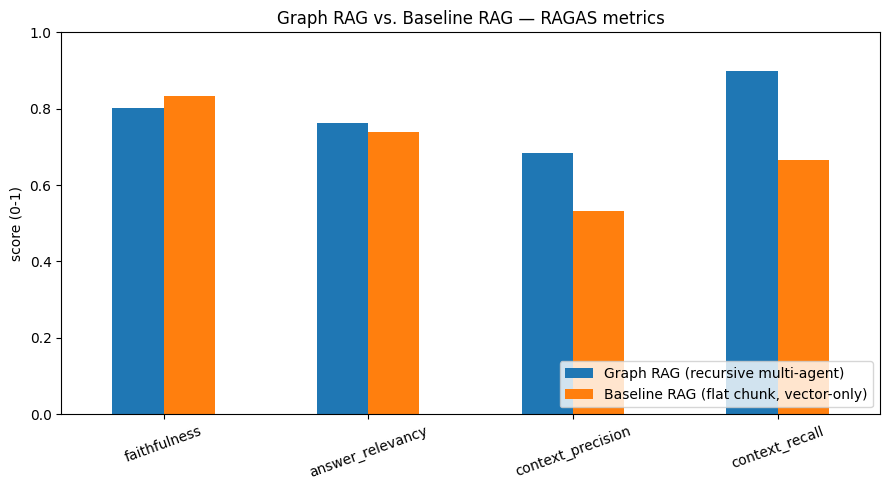

In [ ]:
import matplotlib.pyplot as plt

metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

summary = pd.DataFrame({
    "Graph RAG (recursive multi-agent)": graph_scores_df[metric_cols].mean(),
    "Baseline RAG (flat chunk, vector-only)": baseline_scores_df[metric_cols].mean(),
}).round(3)

display(summary)

ax = summary.plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
ax.set_title("Graph RAG vs. Baseline RAG — RAGAS metrics")
ax.set_ylabel("score (0-1)")
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()